In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
#import gget

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

import scvi
from scvi.external import SysVI

import cupy as cp
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

# Enable `managed_memory`
# rmm.reinitialize(
#     managed_memory=True,
#     pool_allocator=False,
# )
# cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 3

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/bone_marrow_processed.h5ad"
adata = sc.read_h5ad(fpath)
adata

CPU times: user 249 ms, sys: 733 ms, total: 982 ms
Wall time: 3.04 s


AnnData object with n_obs × n_vars = 5608 × 22954
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'leiden', 'bm_cluster', 'CD34_avg', 'CD164_avg', 'PROM1_avg', 'CD48_avg', 'FLT3_avg', 'MPO_avg', 'IRF8_avg', 'CD79A_avg', 'GATA1_avg', 'CD34pos_CD38neg_B0251_HTO_1', 'CD34pos_CD38pos_B0252_HTO_2', 'HTO_pred', 'HTO_pred_label', 'cluster_preds', 'CD164_mean', 'CD34_mean', 'CD38_mean', 'THY1_mean', 'PTPRC_mean', 'MME_mean', 'CD7_mean', 'FLT3_mean', 'PLEK_mean', 'BST2_mean', 'CD37_mean', 'KIT_mean', 'ICAM3_mean', 'CD44_mean', 'EVI2B_mean', 'CD63_mean', 'ITGA2B_mean', 'CSF2RB_mean', 'PROM1_mean', 'ATP1B3_mean',

# Barcode Data

### Read in data

In [3]:
fpath = "/scratch/indikar_root/indikar1/shared_data/bone_marrow_hashes_multi/feature_barcodes/fbc_map.csv"
df = pd.read_csv(fpath)

df['cell_barcode'] = df['cell_barcode'] + "-1"
df = df.drop(columns='pred')
df = pd.melt(df, id_vars='cell_barcode')

df["variable"] = df["variable"].str.replace(r"^chunk_\d+_", "", regex=True)
print(list(df['variable'].unique()))

['CD133', 'CD34', 'CD34p_CD38n', 'CD34p_CD38p', 'CD45RA', 'CD49f', 'CD90']


### Quick Overview + Cleanup

In [4]:
print(f"Total cells: {df['cell_barcode'].nunique()}")
print(f"Total reads: {df['value'].sum()}")
print(f"Mean reads/cell: {df['value'].sum() / df['cell_barcode'].nunique()}")

print(f"\n\n---- Total Reads by Hash Code  ----")
gx = df.groupby('variable')['value'].sum()
print(gx.to_string())

# sum over all chunks (by cell id)
df = df.groupby(['cell_barcode', 'variable'])['value'].sum().reset_index()
df = pd.pivot_table(df, index='cell_barcode', columns='variable', values='value', fill_value=0.0)

df = df.reindex(adata.obs_names) 
prediction_targets = ['CD34p_CD38n', 'CD34p_CD38p']
df['hash_prediction'] = (df[prediction_targets]).idxmax(axis=1)

print(f"\n\n---- Predictions by Hash Code  ----")
print(df['hash_prediction'].value_counts().to_string())

# Drop hash counts, not useful once we have predictions
df = df.drop(['CD34p_CD38n', 'CD34p_CD38p'], axis=1)


print(f"\n\n----Clean DataFrame ----")
print(df.head().to_string())

Total cells: 6292
Total reads: 914878.0
Mean reads/cell: 145.4033693579148


---- Total Reads by Hash Code  ----
variable
CD133           20997.0
CD34            87791.0
CD34p_CD38n    560780.0
CD34p_CD38p     83560.0
CD45RA          62348.0
CD49f           19176.0
CD90            80226.0


---- Predictions by Hash Code  ----
hash_prediction
CD34p_CD38n    5008
CD34p_CD38p     592


----Clean DataFrame ----
variable            CD133  CD34  CD45RA  CD49f  CD90 hash_prediction
AAACCAAAGGCGATCT-1    0.0   1.0     2.0    0.0   1.0     CD34p_CD38n
AAACCAAAGGTGAACG-1    3.0   4.0     4.0    3.0   7.0     CD34p_CD38n
AAACCATTCCCTGTCA-1    1.0   6.0     0.0    3.0   3.0     CD34p_CD38n
AAACCATTCCGCGATG-1    2.0   9.0     2.0    1.0   2.0     CD34p_CD38n
AAACCATTCCTGTCGC-1    1.0   2.0     0.0    0.0   2.0     CD34p_CD38n


/tmp/ipykernel_1646579/2677991517.py:15: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df['hash_prediction'] = (df[prediction_targets]).idxmax(axis=1)


# Filtering

## CellRanger-esque aggregate filtering

In [5]:
# define our antibody list
features = ['CD34', 'CD90', 'CD133', 'CD45RA', 'CD49f']

In [6]:
high_ct_features = []

for f in features:
    if df[f].max() >= 1000:
        high_ct_features.append(f)

print(high_ct_features)

['CD34', 'CD90', 'CD133', 'CD45RA', 'CD49f']


In [7]:
ft_threshold = dict()

if len(high_ct_features) >= 5:
    for h in high_ct_features:
        counts = df[h]
        counts = counts.sort_values(ascending=False)

        if counts.shape[0] >= 25:
            t_f = counts.iloc[25]
        
        else:
            t_f = counts[(counts.shape[0] - 1)]

        ft_threshold[h] = t_f

else:
    print("no aggregate barcodes")

print(ft_threshold)

{'CD34': np.float64(202.0), 'CD90': np.float64(189.0), 'CD133': np.float64(36.0), 'CD45RA': np.float64(154.0), 'CD49f': np.float64(43.0)}


In [8]:
print(df.head())

variable            CD133  CD34  CD45RA  CD49f  CD90 hash_prediction
AAACCAAAGGCGATCT-1    0.0   1.0     2.0    0.0   1.0     CD34p_CD38n
AAACCAAAGGTGAACG-1    3.0   4.0     4.0    3.0   7.0     CD34p_CD38n
AAACCATTCCCTGTCA-1    1.0   6.0     0.0    3.0   3.0     CD34p_CD38n
AAACCATTCCGCGATG-1    2.0   9.0     2.0    1.0   2.0     CD34p_CD38n
AAACCATTCCTGTCGC-1    1.0   2.0     0.0    0.0   2.0     CD34p_CD38n


In [9]:
pdf = df.drop('hash_prediction', axis=1)
total_umi = pdf.sum(axis=1)
umi_cutoff = total_umi.quantile(0.995)

print(umi_cutoff)

573.9000000000087


In [10]:
# since we have only 5 antibodies, reasonable to call something an aggregate only if all 5 antibodies are above per feature thresholds

# high count in all features
per_feature_masks = [(pdf[f] >= ft_threshold[f]) for f in features]
all_features_high = np.logical_and.reduce(per_feature_masks)

# total UMI in top 0.5%
# high_total_umi = total_umi >= umi_cutoff

# combined 
aggregate_mask = all_features_high

# get aggregate barcodes
aggregate_indices = pdf.index[aggregate_mask]

print("Number of aggregate barcodes:", aggregate_indices.shape[0])

Number of aggregate barcodes: 22


In [11]:
print(df.shape)
df = df.drop(aggregate_indices)
print(df.shape)

(5608, 6)
(5586, 6)


## Some additional filtering

In [12]:
# Remove cells with no CD34
print(df.shape)
df = df[df['CD34'] > 0]
print(df.shape)

(5586, 6)
(5511, 6)


# Merge with adata.obs

In [13]:
adata.obs = adata.obs.join(df)    
adata.obs.head()

,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,LAIR1_mean,CD74_mean,SELL_mean,cell_labels,CD133,CD34,CD45RA,CD49f,CD90,hash_prediction
AAACCAAAGGCGATCT-1,bone_marrow,7035,8.858795,44635.0,10.706296,34.950151,49.842052,57.302565,66.010978,1521.0,...,0.512722,2.758574,1.337802,MPP,0.0,1.0,2.0,0.0,1.0,CD34p_CD38n
AAACCAAAGGTGAACG-1,bone_marrow,4440,8.398635,21652.0,9.982900,37.091262,51.533346,59.763532,69.517827,639.0,...,0.125927,1.277790,0.186091,MEG/ERY,3.0,4.0,4.0,3.0,7.0,CD34p_CD38n
AAACCATTCCCTGTCA-1,bone_marrow,6370,8.759512,40379.0,10.606090,33.547141,47.425642,56.833998,66.601451,1230.0,...,0.454510,2.544269,1.247767,CMP,1.0,6.0,0.0,3.0,3.0,CD34p_CD38n
AAACCATTCCGCGATG-1,bone_marrow,3872,8.261785,15760.0,9.665294,37.912437,51.979695,59.904822,69.302030,545.0,...,0.436981,2.921885,1.327408,HSC,2.0,9.0,2.0,1.0,2.0,CD34p_CD38n
AAACCATTCCTGTCGC-1,bone_marrow,4817,8.480114,19367.0,9.871378,30.897919,43.754841,52.253834,62.621986,624.0,...,0.512722,2.758574,1.337802,MPP,1.0,2.0,0.0,0.0,2.0,CD34p_CD38n


### Log-transform surface protein marks

In [14]:
for f in features:
    adata.obs[f"log_{f}"] = np.log1p(adata.obs[f].to_numpy())
    #print(adata.obs[f].head())
    #print(adata.obs[f"log_{f}"].head())
adata.obs["CD34_fb"] = adata.obs["CD34"]
adata.obs = adata.obs.drop(columns=["CD34"])

adata.obs.head()

,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,CD45RA,CD49f,CD90,hash_prediction,log_CD34,log_CD90,log_CD133,log_CD45RA,log_CD49f,CD34_fb
AAACCAAAGGCGATCT-1,bone_marrow,7035,8.858795,44635.0,10.706296,34.950151,49.842052,57.302565,66.010978,1521.0,...,2.0,0.0,1.0,CD34p_CD38n,0.693147,0.693147,0.000000,1.098612,0.000000,1.0
AAACCAAAGGTGAACG-1,bone_marrow,4440,8.398635,21652.0,9.982900,37.091262,51.533346,59.763532,69.517827,639.0,...,4.0,3.0,7.0,CD34p_CD38n,1.609438,2.079442,1.386294,1.609438,1.386294,4.0
AAACCATTCCCTGTCA-1,bone_marrow,6370,8.759512,40379.0,10.606090,33.547141,47.425642,56.833998,66.601451,1230.0,...,0.0,3.0,3.0,CD34p_CD38n,1.945910,1.386294,0.693147,0.000000,1.386294,6.0
AAACCATTCCGCGATG-1,bone_marrow,3872,8.261785,15760.0,9.665294,37.912437,51.979695,59.904822,69.302030,545.0,...,2.0,1.0,2.0,CD34p_CD38n,2.302585,1.098612,1.098612,1.098612,0.693147,9.0
AAACCATTCCTGTCGC-1,bone_marrow,4817,8.480114,19367.0,9.871378,30.897919,43.754841,52.253834,62.621986,624.0,...,0.0,0.0,2.0,CD34p_CD38n,1.098612,1.098612,0.693147,0.000000,0.000000,2.0


# Plotting!

In [16]:
from matplotlib.colors import LinearSegmentedColormap

low = '#131317' # dark
mid = '#3B80EB' # blue
high = '#F2D123' # yellow

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0.0, low), (0.15, low), (0.5, mid), (0.85, high), (1.0, high)]
)

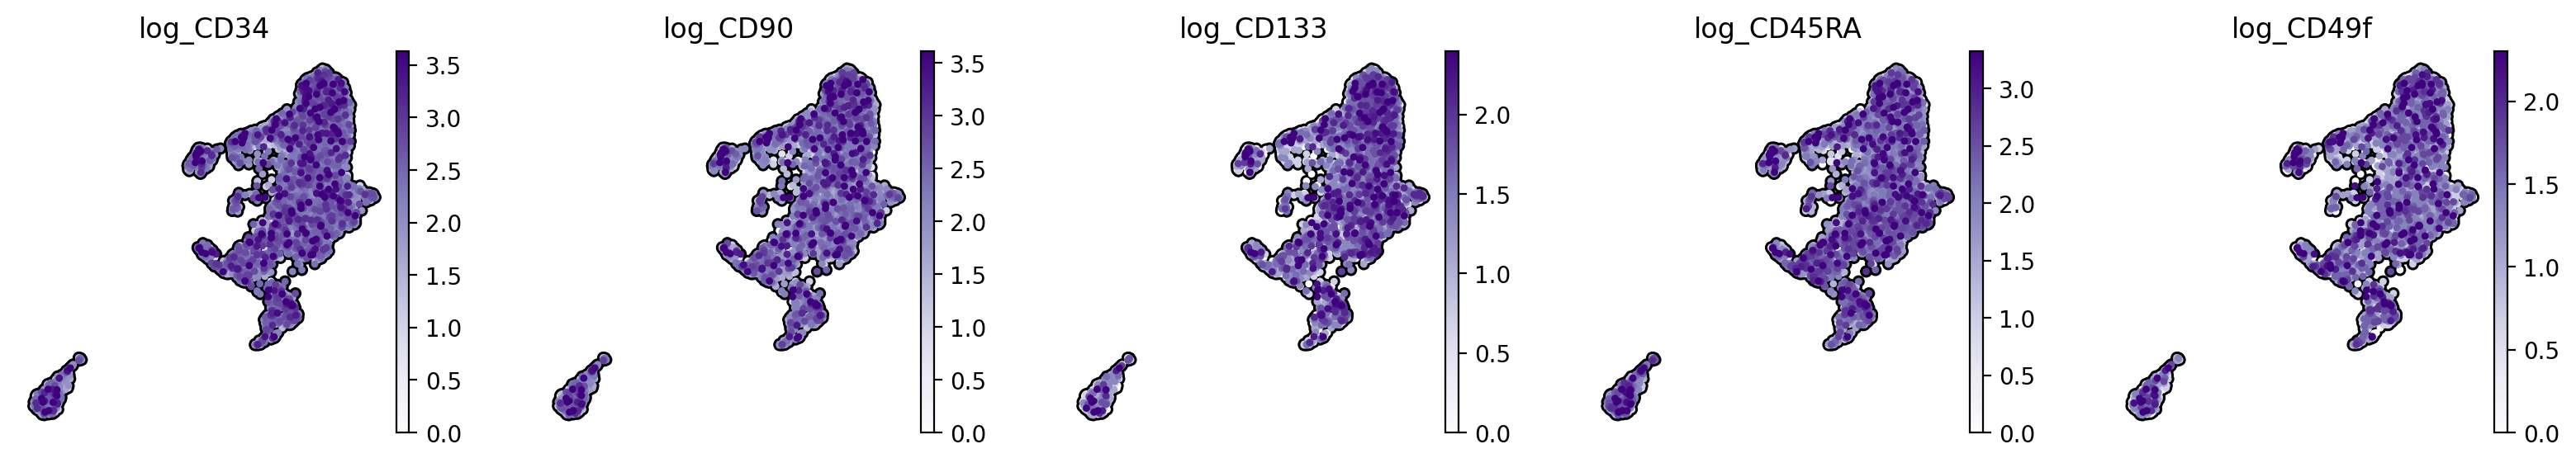

In [42]:
plot_cols = ['log_CD34', 'log_CD90', 'log_CD133', 'log_CD45RA', 'log_CD49f']

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.umap(
    adata,
    color=plot_cols,
    size=40,
    ncols=5,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
    # cmap=custom_cmap,
    cmap='Purples',
    vmin=0,
    vmax='p98',
    # title='',
    # legend_loc='none',
)

In [36]:
n_bins = 3  # low / mid / high

adata.obs['CD90_bin'] = pd.qcut(
    adata.obs['log_CD90'],
    q=n_bins,
    labels=[f'Q{i+1}' for i in range(n_bins)]
)

# Ensure categorical dtype
adata.obs['CD90_bin'] = adata.obs['CD90_bin'].astype('category')

sc.tl.embedding_density(
    adata, 
    basis='umap',
    groupby='CD90_bin',
)

computing density on 'umap'
--> added
    'umap_density_CD90_bin', densities (adata.obs)
    'umap_density_CD90_bin_params', parameter (adata.uns)


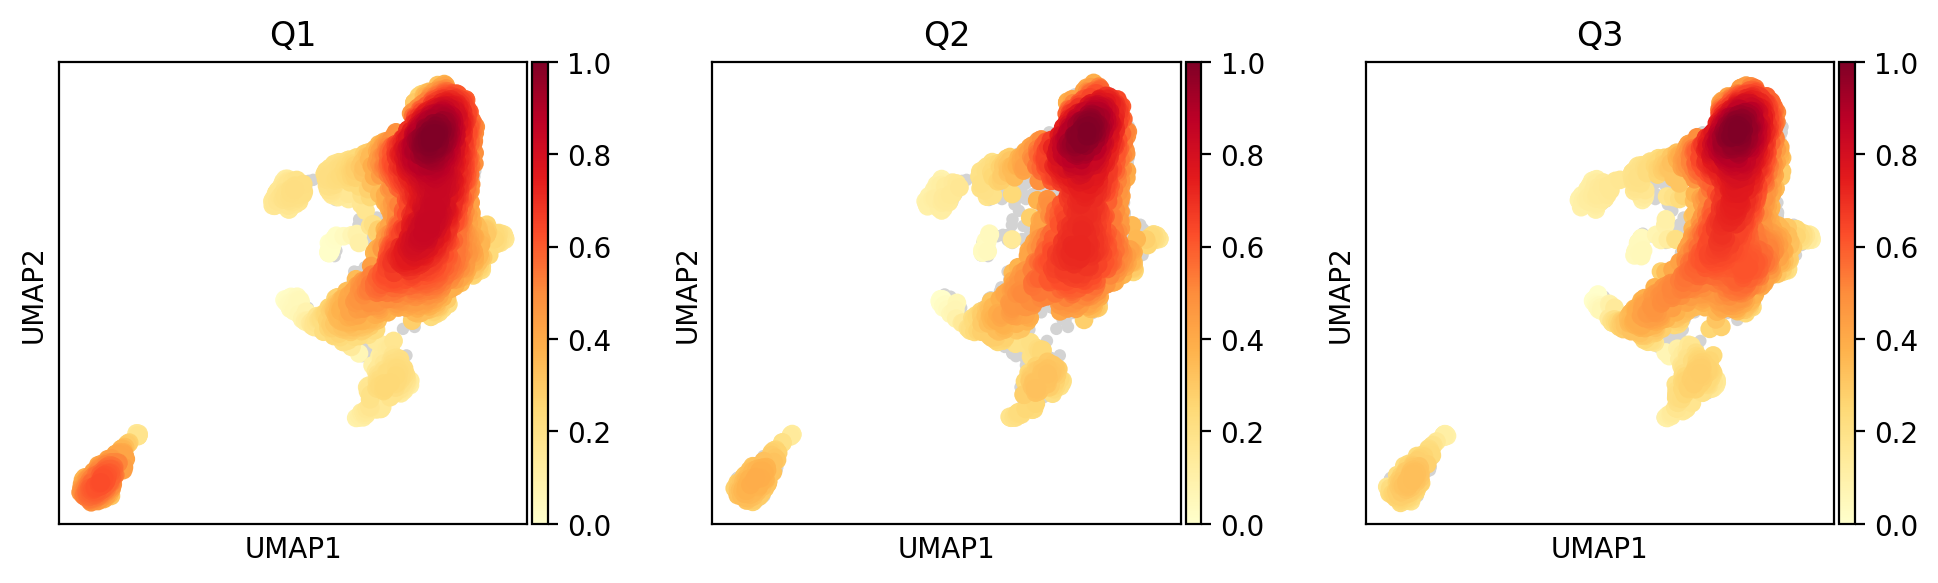

In [40]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sc.pl.embedding_density(
    adata,
    basis='umap',
    groupby='CD90_bin',
    # size=40,
    # ncols=3,
    # add_outline=True,
    # outline_color=('k', 'k'),
    # frameon=False,
    # alpha=1,
    # # cmap=custom_cmap,
    # cmap='Purples',
    # vmin='p2',
    # vmax='p98',
)

In [15]:
features = ['CD34', 'CD90', 'CD133', 'CD45RA', 'CD49f'] # in obs
genes = ['CD34', 'THY1', 'PROM1', 'PTPRC', 'ITGA6'] # in vars

In [16]:
pairs = list(zip(features, genes))

# UMAP coords
umap = adata.obsm["X_umap"]
x = umap[:, 0]
y = umap[:, 1]

In [17]:
# column scales
rna_vals_all = []
adt_vals_all = []

for feat, gene in pairs:
    rna_vals = np.asarray(adata[:, gene].X).ravel()
    adt_vals = adata.obs[f"log_{feat}"].astype(float).to_numpy()

    rna_vals_all.append(rna_vals)
    adt_vals_all.append(adt_vals)

rna_vals_all = np.concatenate(rna_vals_all)
adt_vals_all = np.concatenate(adt_vals_all)

rna_finite = rna_vals_all[np.isfinite(rna_vals_all)]
adt_finite = adt_vals_all[np.isfinite(adt_vals_all)]

rna_vmin, rna_vmax = np.nanmin(rna_finite), np.nanmax(rna_finite)
adt_vmin, adt_vmax = np.nanmin(adt_finite), np.nanmax(adt_finite)

print("RNA vmin/vmax:", rna_vmin, rna_vmax)
print("ADT vmin/vmax:", adt_vmin, adt_vmax)

RNA vmin/vmax: 0.0 3.1319144
ADT vmin/vmax: 0.0 5.58724865840025


In [19]:
# import palettable

# from palettable.scientific.sequential import Batlow_9
# from matplotlib.colors import ListedColormap
# from cmap import Colormap
# cet = Colormap('colorcet:CET_CBL2').to_mpl()

# # new cet colors
# newc = cet(np.linspace(0,1,256))
# top = cet(0.85)
# newc[220:, :] = top
# newmap = ListedColormap(newc,name='new_cet')
# newmap

In [20]:
from matplotlib.colors import LinearSegmentedColormap

low = '#131317' # dark
mid = '#3B80EB' # blue
high = '#F2D123' # yellow

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0.0, low), (0.15, low), (0.5, mid), (0.85, high), (1.0, high)]
)

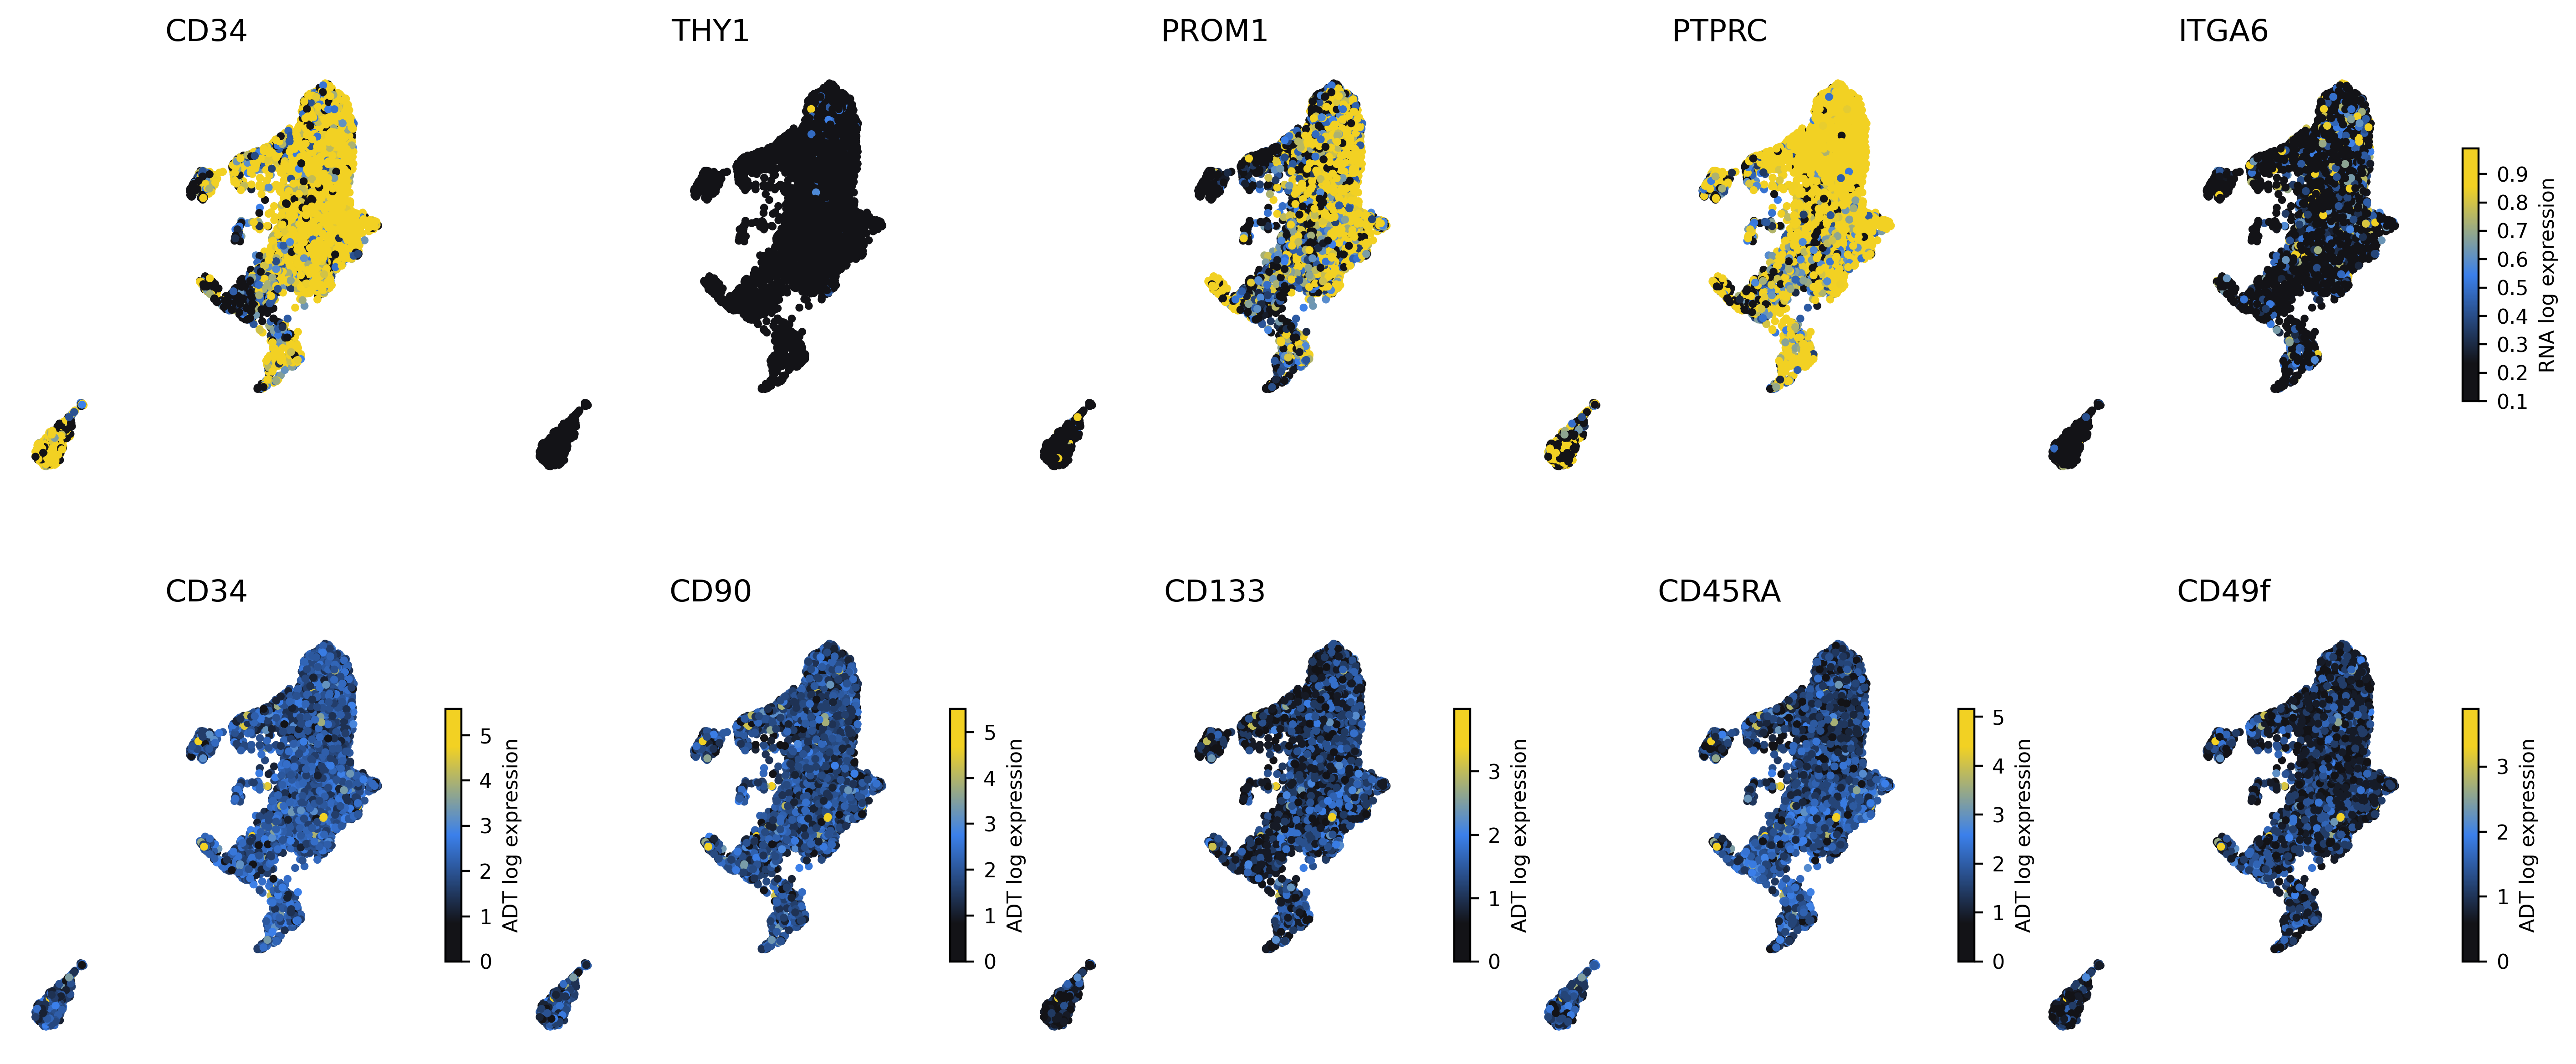

In [53]:
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator

n = len(pairs)
plt.rcParams['figure.dpi'] = 400

fig = plt.figure(figsize=(3.2 * n + 1.5, 7))

# Columns: [UMAP, cbar] * n
widths = [1, 0.07] * n
gs = GridSpec(
    2, 2 * n,
    width_ratios=widths,
    wspace=0.25,
    hspace=0.33
)

# ------------------ RNA ROW ------------------
for j, (feat, gene) in enumerate(pairs):
    col = 2 * j  # UMAP columns: 0,2,4,...,2*(n-1)
    ax = fig.add_subplot(gs[0, col])

    rna_vals = np.asarray(adata[:, gene].X).ravel()

    sc_rna = ax.scatter(
        x, y,
        c=rna_vals,
        cmap=custom_cmap,
        s=10,
        linewidths=0,
        vmin=0.1,
        vmax=0.99
    )

    ax.text(
        0.5, 1.04, gene,
        transform=ax.transAxes,
        ha="center", va="bottom", fontsize=12
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    # If you want 1:1 aspect:
    # ax.set_aspect("equal", adjustable="box")

# RNA colorbar in the *last* column, top row
# This shares a column with the last ADT colorbar
cax_rna = fig.add_subplot(gs[0, -1])
cb1 = fig.colorbar(sc_rna, cax=cax_rna, orientation="vertical", shrink=0.05)
cb1.set_label("RNA log expression", fontsize=8)
cb1.locator = MaxNLocator(integer=True)
cb1.update_ticks()
cb1.ax.tick_params(labelsize=8)

box = cax_rna.get_position()
cax_rna.set_position([
    box.x0,
    box.y0 + box.height * 0.2,
    box.width * 0.6,
    box.height * 0.6,
])

# ------------------ ADT ROW (per-feature scale, vmin=0, integer ticks) ------------------
for j, (feat, gene) in enumerate(pairs):
    col = 2 * j  # UMAP columns: 0,2,4,...,2*(n-1)
    ax = fig.add_subplot(gs[1, col])

    adt_vals = adata.obs[f"log_{feat}"].astype(float).to_numpy()

    finite = np.isfinite(adt_vals)
    if np.any(finite):
        vmax = np.nanmax(adt_vals[finite])
    else:
        vmax = 1.0

    vmin = 0.0  # always include 0
    
    sc_adt = ax.scatter(
        x, y,
        c=adt_vals,
        cmap=custom_cmap,
        s=10,
        linewidths=0,
        vmin=vmin,
        vmax=vmax,
    )

    ax.text(
        0.5, 1.04, feat,
        transform=ax.transAxes,
        ha="center", va="bottom", fontsize=12
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    # ax.set_aspect("equal", adjustable="box")

    # ADT colorbar in the next column (1,3,5,...,2*n-1)
    cax = fig.add_subplot(gs[1, col + 1])
    cb = fig.colorbar(sc_adt, cax=cax, orientation="vertical", shrink=0.05)
    cb.set_label("ADT log expression", fontsize=8)

    cb.locator = MaxNLocator(integer=True)
    cb.update_ticks()
    cb.ax.tick_params(labelsize=8)
    box = cax.get_position()
    cax.set_position([
        box.x0,
        box.y0 + box.height * 0.2,
        box.width * 0.6,
        box.height * 0.6,
    ])

plt.show()


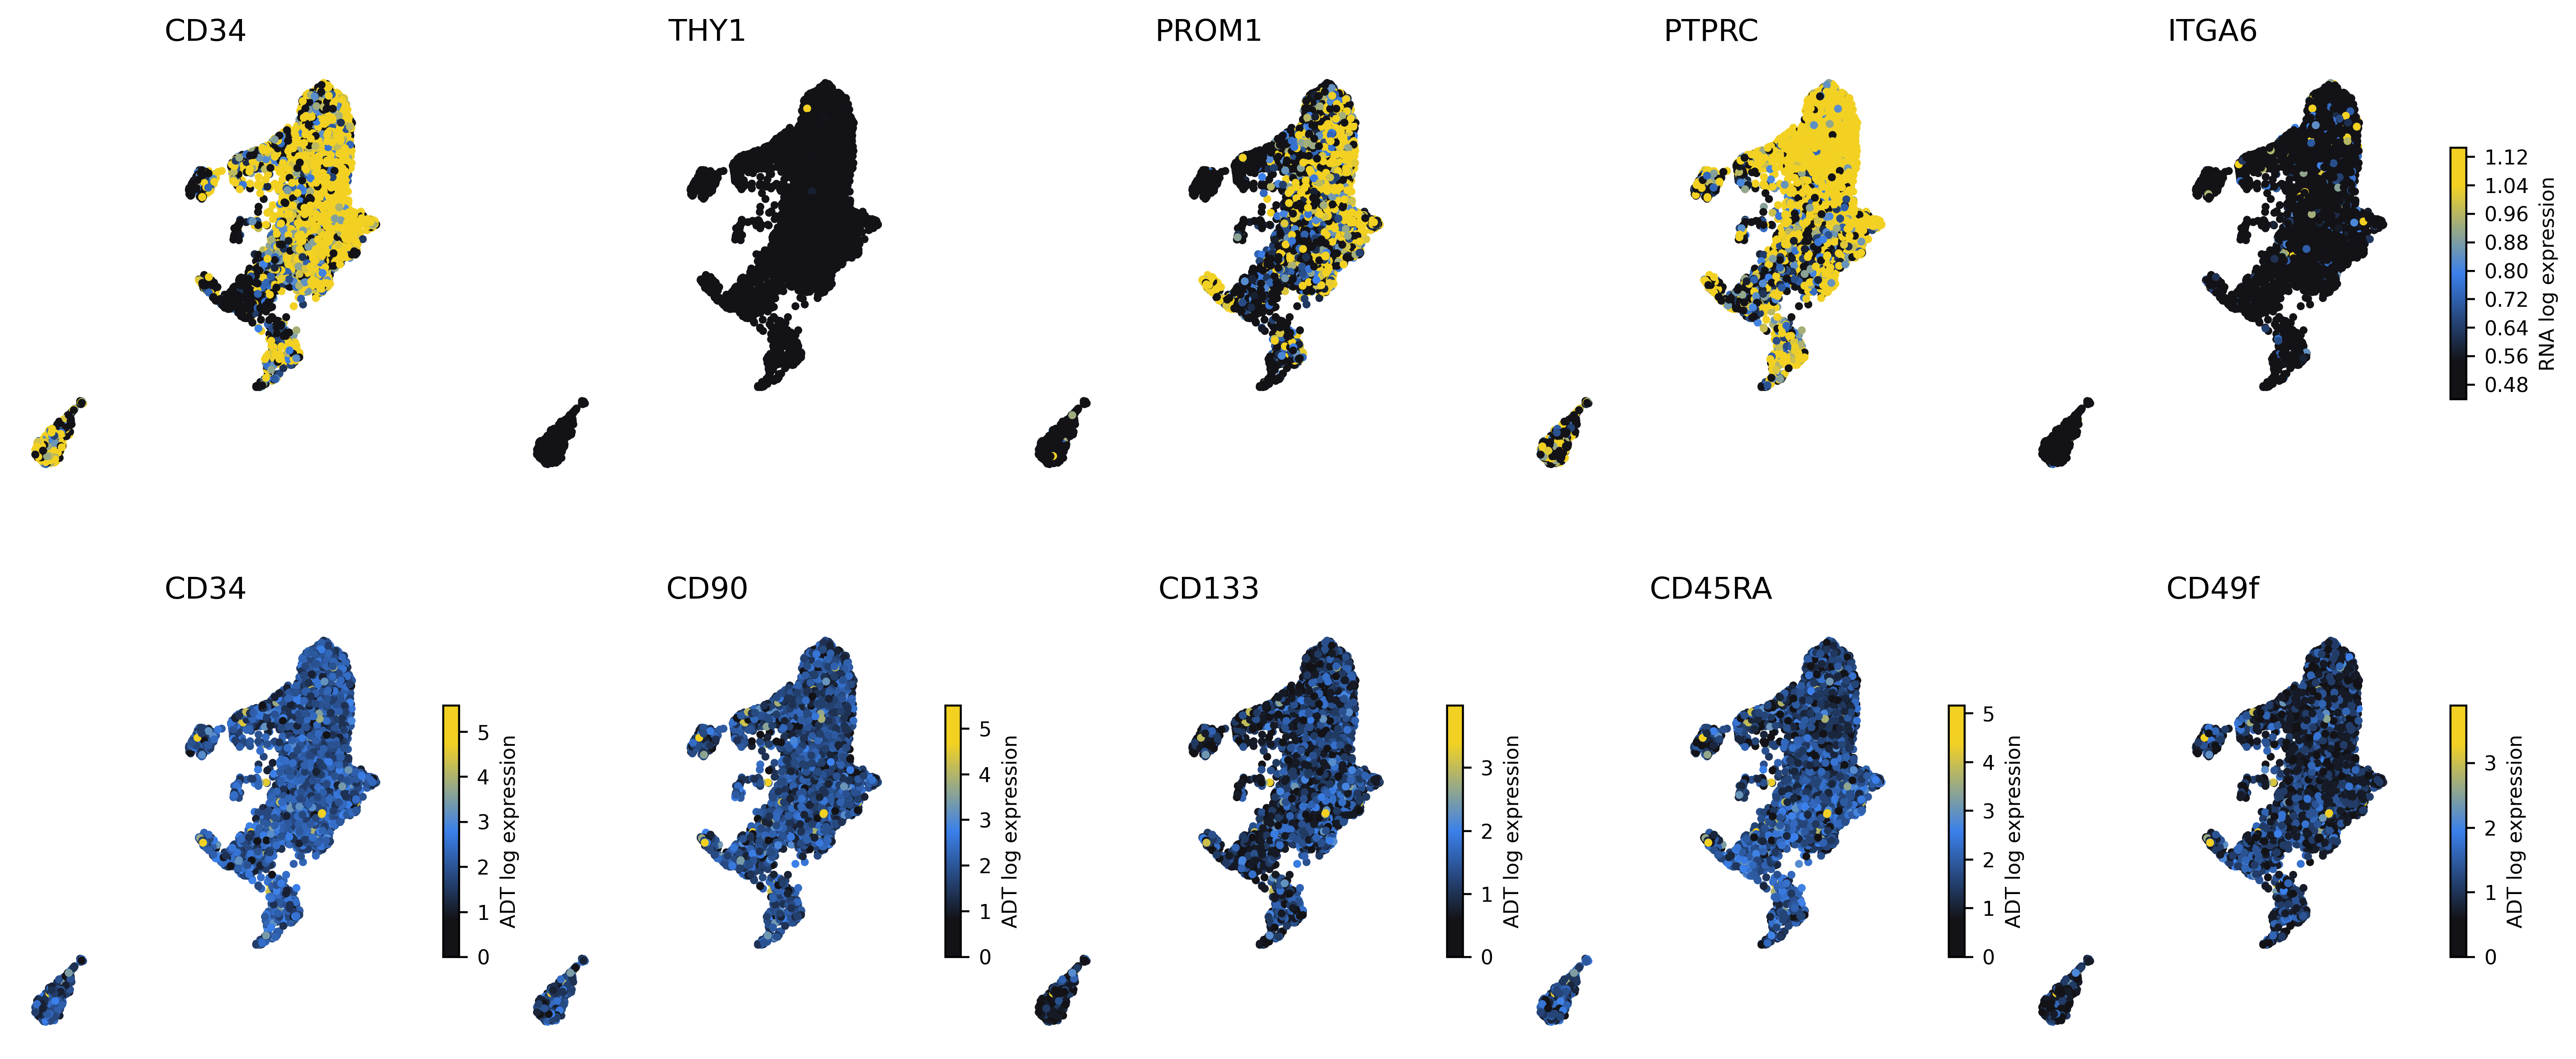

In [22]:
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator

n = len(pairs)
plt.rcParams['figure.dpi'] = 400

fig = plt.figure(figsize=(3.2 * n + 1.5, 7))

# Columns: [UMAP, cbar] * n
widths = [1, 0.07] * n
gs = GridSpec(
    2, 2 * n,
    width_ratios=widths,
    wspace=0.25,
    hspace=0.33
)

# ------------------ RNA ROW ------------------
rna_finite = rna_vals[np.isfinite(rna_vals)]
rna_vmin = np.nanpercentile(rna_finite, 85)
rna_vmax = np.nanpercentile(rna_finite, 99)

for j, (feat, gene) in enumerate(pairs):
    col = 2 * j  # UMAP columns: 0,2,4,...,2*(n-1)
    ax = fig.add_subplot(gs[0, col])

    rna_vals = np.asarray(adata[:, gene].X).ravel()

    sc_rna = ax.scatter(
        x, y,
        c=rna_vals,
        cmap=custom_cmap,
        s=10,
        linewidths=0,
        vmin=rna_vmin,
        vmax=rna_vmax
    )

    ax.text(
        0.5, 1.04, gene,
        transform=ax.transAxes,
        ha="center", va="bottom", fontsize=12
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    # If you want 1:1 aspect:
    # ax.set_aspect("equal", adjustable="box")

# RNA colorbar in the *last* column, top row
# This shares a column with the last ADT colorbar
cax_rna = fig.add_subplot(gs[0, -1])
cb1 = fig.colorbar(sc_rna, cax=cax_rna, orientation="vertical", shrink=0.05)
cb1.set_label("RNA log expression", fontsize=8)
cb1.locator = MaxNLocator(integer=True)
cb1.update_ticks()
cb1.ax.tick_params(labelsize=8)

box = cax_rna.get_position()
cax_rna.set_position([
    box.x0,
    box.y0 + box.height * 0.2,
    box.width * 0.6,
    box.height * 0.6,
])

# ------------------ ADT ROW (per-feature scale, vmin=0, integer ticks) ------------------
for j, (feat, gene) in enumerate(pairs):
    col = 2 * j  # UMAP columns: 0,2,4,...,2*(n-1)
    ax = fig.add_subplot(gs[1, col])

    adt_vals = adata.obs[f"log_{feat}"].astype(float).to_numpy()

    finite = np.isfinite(adt_vals)
    if np.any(finite):
        vmax = np.nanmax(adt_vals[finite])
    else:
        vmax = 1.0

    vmin = 0.0  # always include 0

    sc_adt = ax.scatter(
        x, y,
        c=adt_vals,
        cmap=custom_cmap,
        s=10,
        linewidths=0,
        vmin=vmin,
        vmax=vmax,
    )

    ax.text(
        0.5, 1.04, feat,
        transform=ax.transAxes,
        ha="center", va="bottom", fontsize=12
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)
    # ax.set_aspect("equal", adjustable="box")

    # ADT colorbar in the next column (1,3,5,...,2*n-1)
    cax = fig.add_subplot(gs[1, col + 1])
    cb = fig.colorbar(sc_adt, cax=cax, orientation="vertical", shrink=0.05)
    cb.set_label("ADT log expression", fontsize=8)

    cb.locator = MaxNLocator(integer=True)
    cb.update_ticks()
    cb.ax.tick_params(labelsize=8)
    box = cax.get_position()
    cax.set_position([
        box.x0,
        box.y0 + box.height * 0.2,
        box.width * 0.6,
        box.height * 0.6,
    ])

plt.show()


In [23]:
features = ['CD34', 'CD90', 'CD133', 'CD45RA', 'CD49f']
group_key = "cell_labels"

# threshold in the same scale as your log_ columns
# e.g. threshold = 0.0 means "log_ value > 0 counts as expressed"
threshold = 1

groups = adata.obs[group_key].astype("category")
group_names = list(groups.cat.categories)

n_groups = len(group_names)
n_feats = len(features)

# rows = cell types, cols = features
perc_matrix = np.zeros((n_groups, n_feats), dtype=float)

for gi, g in enumerate(group_names):
    mask_g = (groups == g)
    n_cells_g = mask_g.sum()
    if n_cells_g == 0:
        continue

    for fi, feat in enumerate(features):
        col = f"log_{feat}"
        vals = adata.obs.loc[mask_g, col].astype(float).to_numpy()
        finite = np.isfinite(vals)
        vals = vals[finite]

        if vals.size == 0:
            perc_matrix[gi, fi] = 0.0
            continue

        expressed = (vals >= threshold)
        perc_matrix[gi, fi] = 100.0 * expressed.sum() / vals.size

# put into a DataFrame for convenience
perc_df = pd.DataFrame(
    perc_matrix,
    index=group_names,
    columns=features
)

In [37]:
perc_df = perc_df.drop(index="NA", errors="ignore")

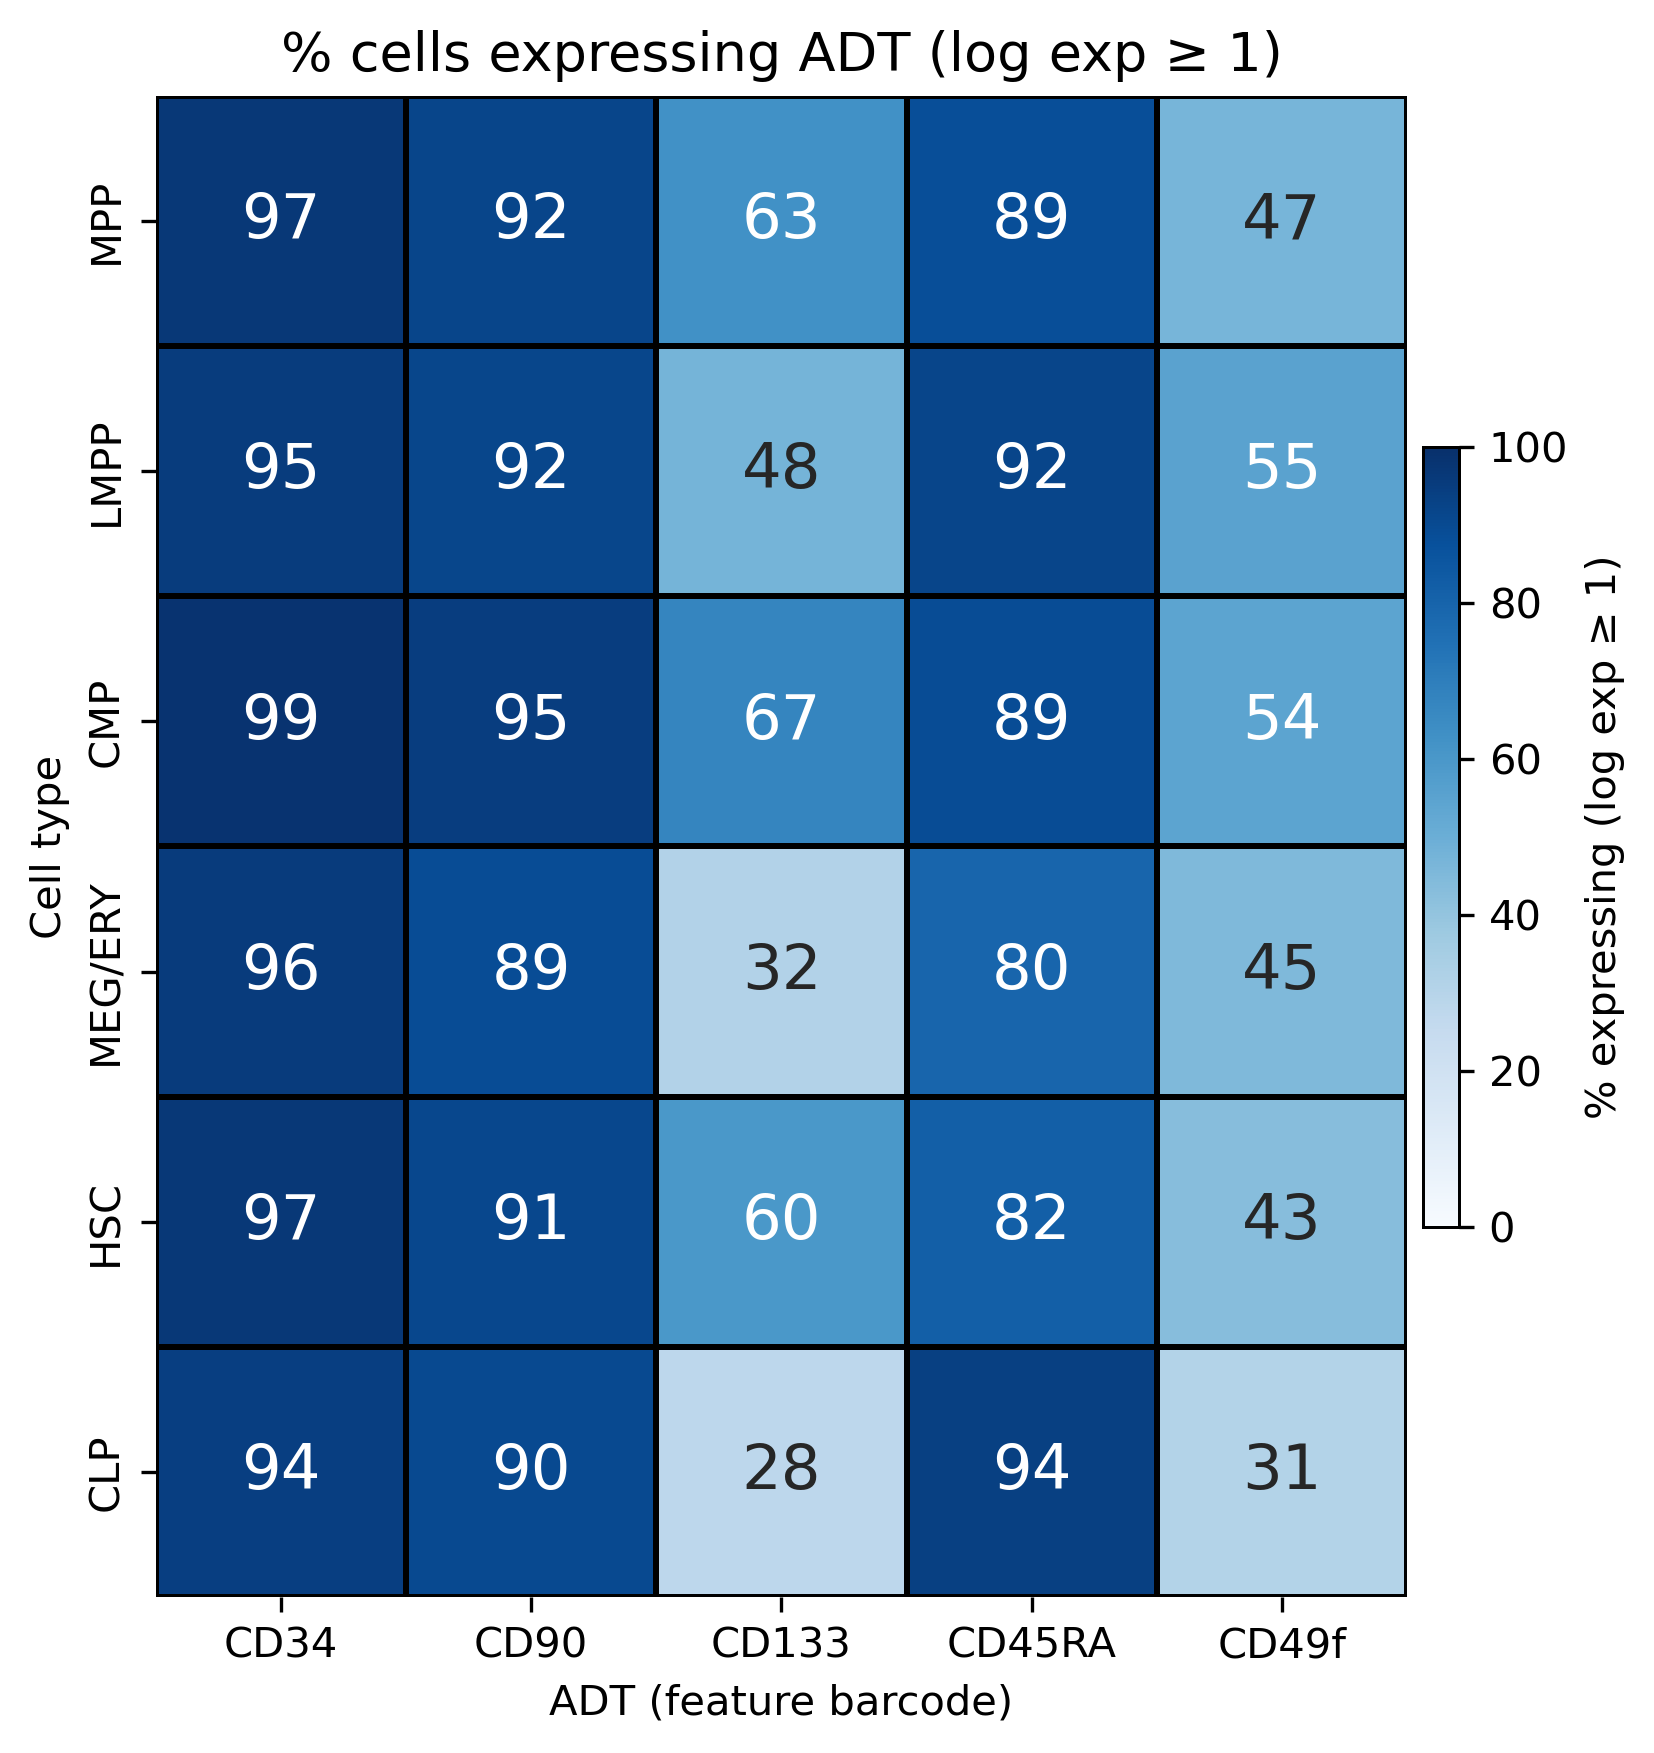

In [48]:
plt.rcParams['figure.dpi'] = 300
fig, ax = plt.subplots(
    figsize=(1 * len(features) + 3, 0.5 * len(group_names) + 3)
)

# Create a small axis for the colorbar (x0, y0, width, height in figure coords)
cax = fig.add_axes([0.78, 0.3, 0.015, 0.4])  # <-- tweak these to taste

sns.heatmap(
    perc_df,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    square=True,
    linewidths=1,
    linecolor="black",
    ax=ax,
    cbar=True,
    cbar_ax=cax,
    cbar_kws={"label": f"% expressing (log exp ≥ {threshold})"},
    annot_kws={"size": 15}
)

for spine in cax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.7)
    spine.set_color("black")

cax.tick_params(labelsize=10)

ax.set_xlabel("ADT (feature barcode)")
ax.set_ylabel("Cell type")
ax.set_title(f"% cells expressing ADT (log exp ≥ {threshold})", fontsize=13)

#plt.tight_layout()  # leave room on right for the colorbar
plt.show()

/tmp/ipykernel_3943180/886146868.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3943180/886146868.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3943180/886146868.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3943180/886146868.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3943180/886146868.py:31: MatplotlibDeprecationWarning: The 'labels' param

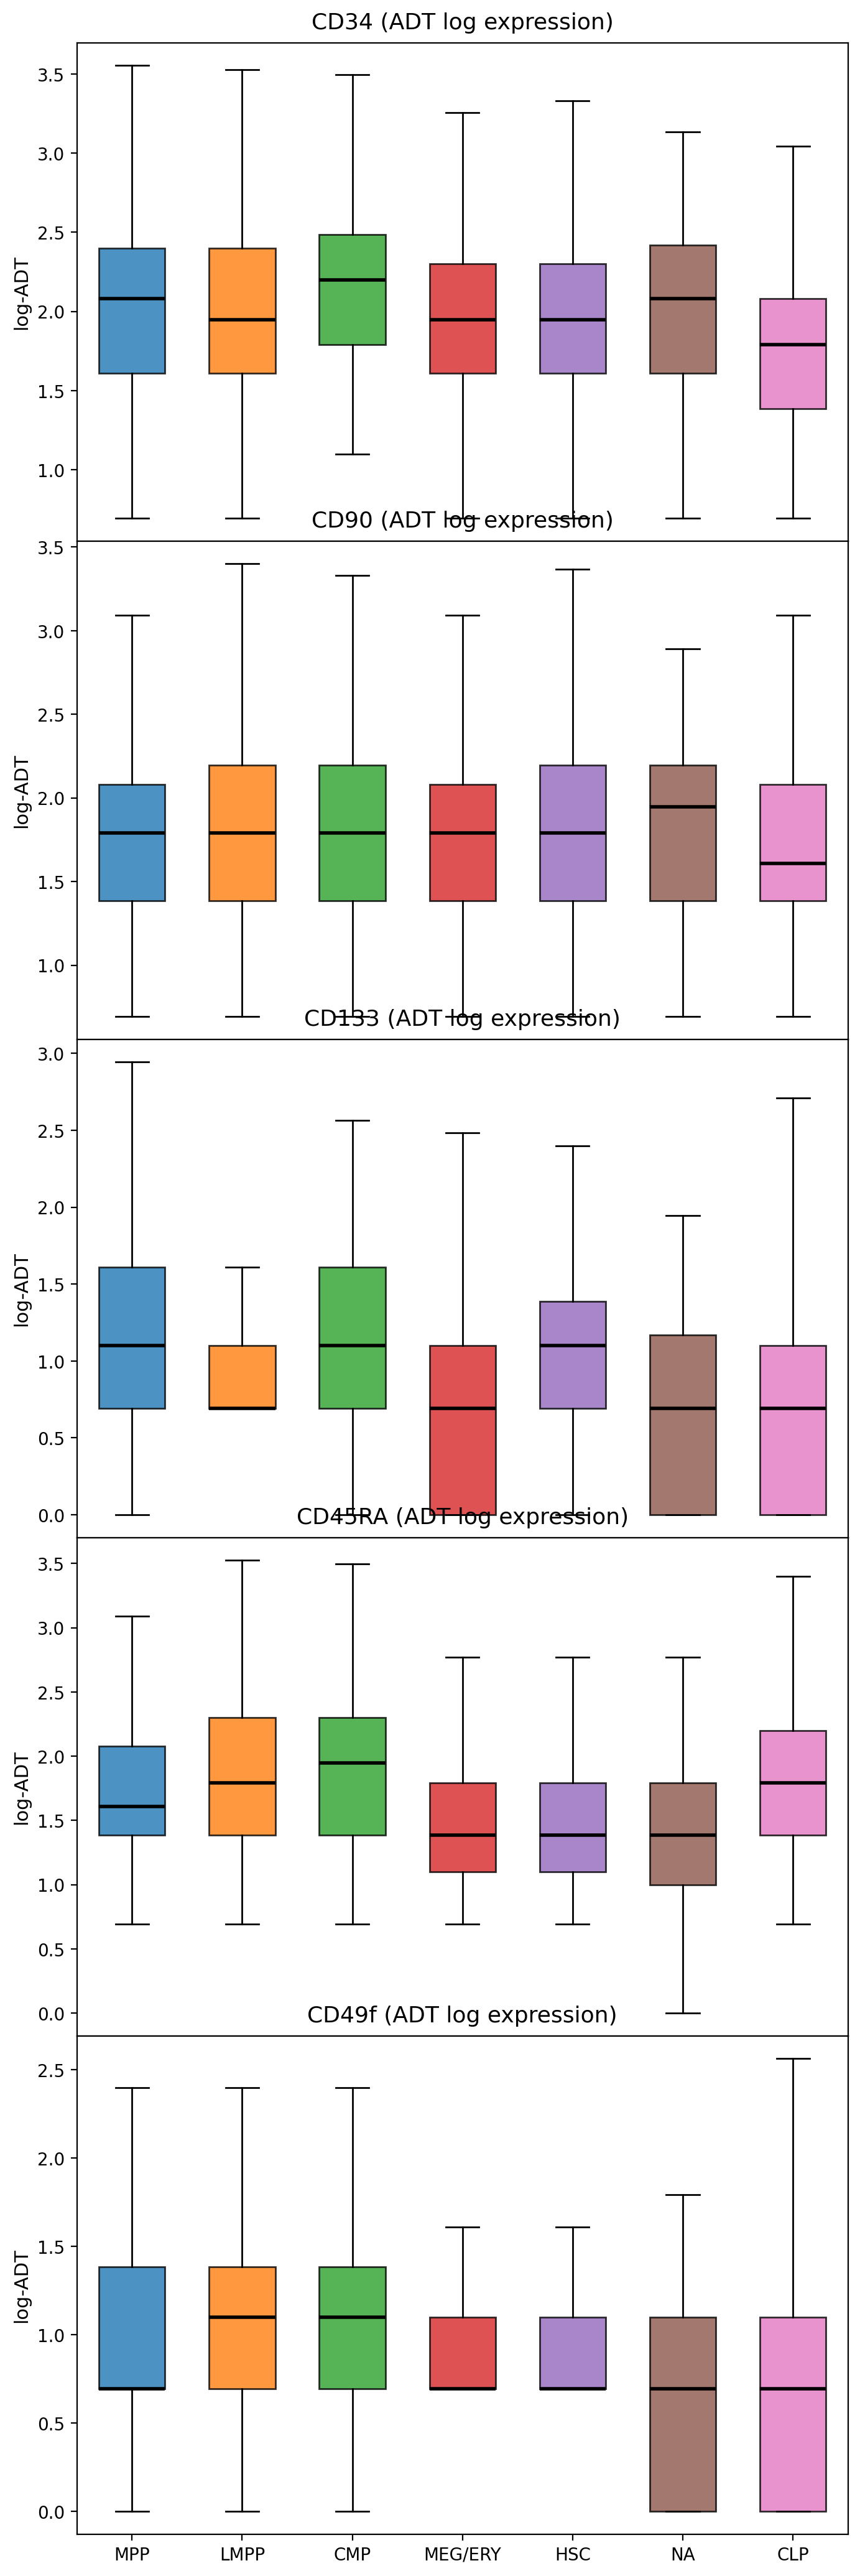

In [25]:
features = ['CD34', 'CD90', 'CD133', 'CD45RA', 'CD49f']
group_key = "cell_labels"

groups = adata.obs[group_key].astype("category")
group_names = list(groups.cat.categories)

palette = adata.uns["cluster_preds_colors"]
assert len(palette) == len(group_names)

n_feats = len(features)

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(
    n_feats, 1,
    figsize=(8.0, 4.5 * n_feats),
    sharex=False              # <-- CRUCIAL so labels don't hide
)

if n_feats == 1:
    axes = [axes]

for ax, feat in zip(axes, features):

    col = f"log_{feat}"
    data = []
    for g in group_names:
        vals = adata.obs.loc[groups == g, col].astype(float)
        vals = vals[np.isfinite(vals)]
        data.append(vals.values)

    bp = ax.boxplot(
        data,
        labels=group_names,
        showfliers=False,
        patch_artist=True,
        widths=0.6
    )

    # color boxes using palette
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    # medians
    for median in bp['medians']:
        median.set_color("black")
        median.set_linewidth(2)

    ax.set_title(f"{feat} (ADT log expression)", fontsize=13, pad=8)
    ax.set_ylabel("log-ADT", fontsize=11)

    # Force labels on *every* subplot
    ax.set_xticks(np.arange(1, len(group_names) + 1))
    ax.set_xticklabels(group_names, rotation=0, fontsize=10)
    ax.tick_params(axis="x", labelbottom=True)

    ax.margins(x=0.15)

# Add more room between rows + bottom padding
plt.subplots_adjust(
    hspace=0.,   # increase spacing between subplots
    bottom=0.08,
    top=0.97
)

plt.show()

In [26]:
## stacked barplot showing proportion of total FB counts per cell type

/tmp/ipykernel_3943180/3031668903.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3943180/3031668903.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3943180/3031668903.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3943180/3031668903.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_3943180/3031668903.py:31: MatplotlibDeprecationWarning: The 'labels' 

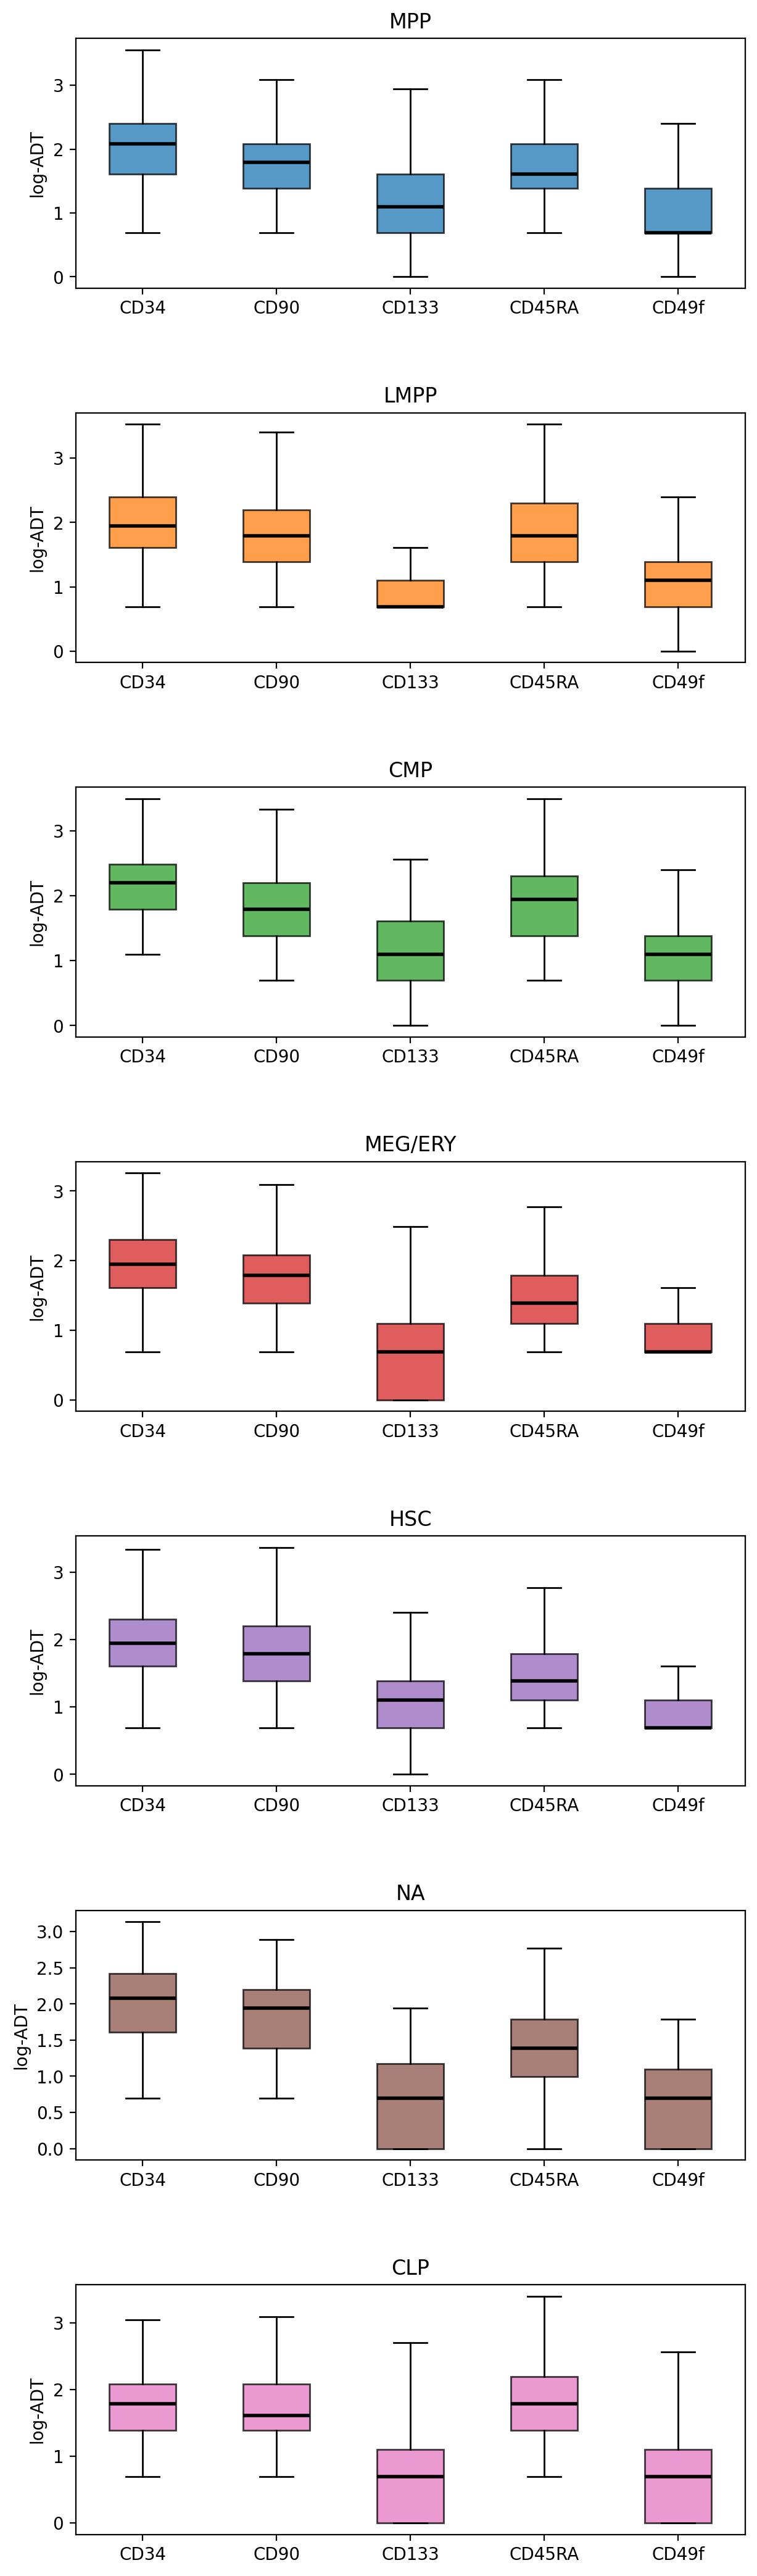

In [27]:
groups = adata.obs[group_key].astype("category")
group_names = list(groups.cat.categories)

# color palette per group (Scanpy-style)
palette = adata.uns["cluster_preds_colors"]
#palette = sns.color_palette("colorblind")
#assert len(palette) == len(group_names)

n_groups = len(group_names)

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(
    n_groups, 1,
    figsize=(7, 3.8 * n_groups),
    sharex=False          # <- important: don't share x to avoid hiding labels
)

if n_groups == 1:
    axes = [axes]

for ax, g, color in zip(axes, group_names, palette):

    # collect distributions: one box per ADT for this cell type
    data = []
    for feat in features:
        col = f"log_{feat}"
        vals = adata.obs.loc[groups == g, col].astype(float)
        vals = vals[np.isfinite(vals)]
        data.append(vals.values)

    bp = ax.boxplot(
        data,
        labels=features,        # ADT names as labels
        showfliers=False,
        patch_artist=True,
        #widths=0.35
    )

    # color all boxes with that cell type's color
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    # # whiskers in same color (2 whiskers per box)
    # for whisker in bp['whiskers']:
    #     whisker.set_color(color)

    for median in bp['medians']:
        median.set_color("black")
        median.set_linewidth(2)

    ax.set_title(str(g), fontsize=12)
    ax.set_ylabel("log-ADT", fontsize=10)

    # explicitly force ticks + labels visible
    ax.set_xticks(np.arange(1, len(features) + 1))
    ax.set_xticklabels(features, rotation=0, fontsize=10)
    ax.tick_params(axis="x", labelbottom=True, bottom=True)

    ax.margins(x=0.02)

# give extra bottom margin so labels don't get cut off
plt.subplots_adjust(bottom=0.12, hspace=0.5)
plt.show()

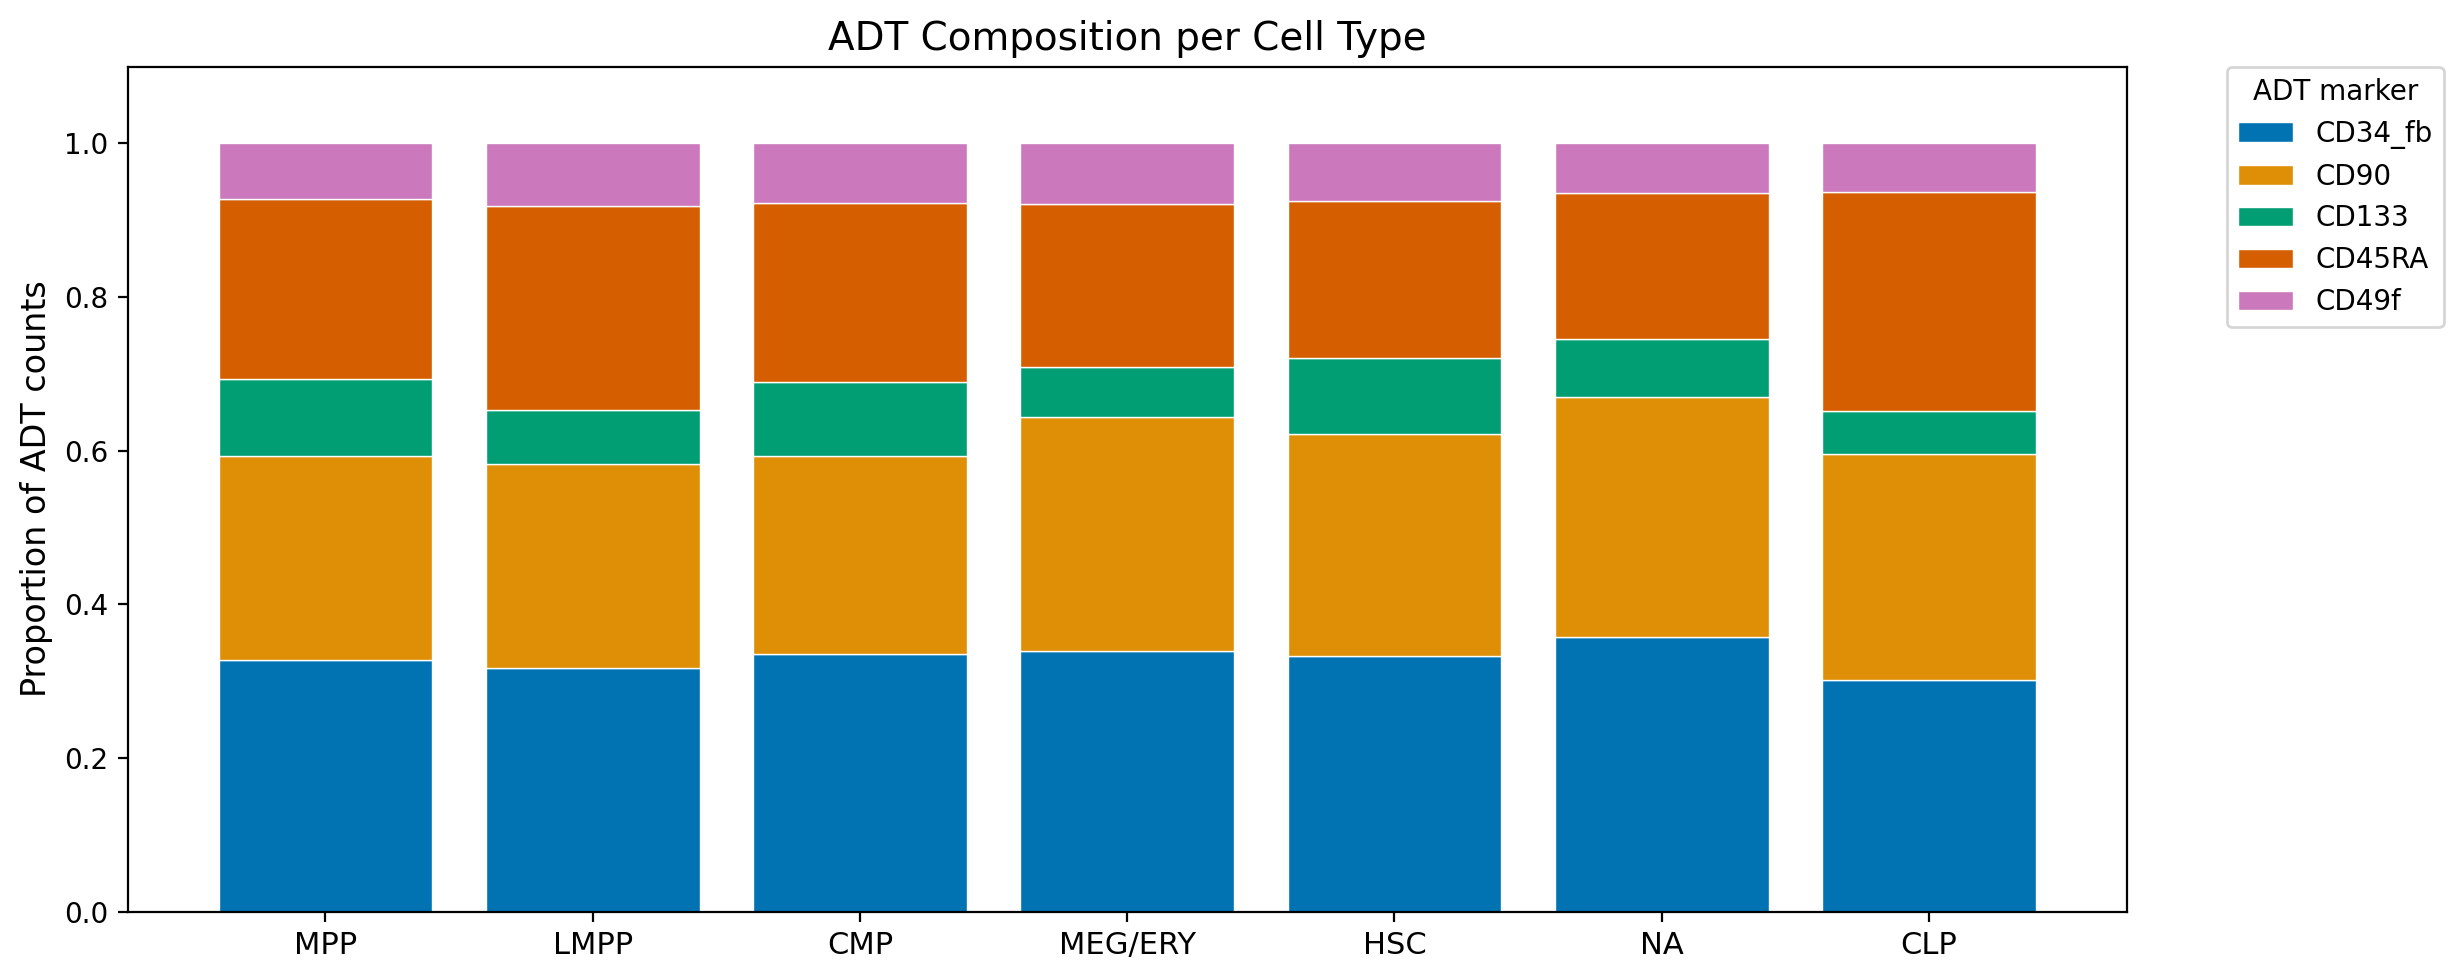

In [28]:
features = ['CD34_fb', 'CD90', 'CD133', 'CD45RA', 'CD49f']
group_key = "cell_labels"

# cell type groups
groups = adata.obs[group_key].astype("category")
group_names = list(groups.cat.categories)
n_groups = len(group_names)
n_feats = len(features)

# use seaborn colorblind palette for ADTs
colors = sns.color_palette("colorblind", n_colors=n_feats)

# matrix: rows = cell types, columns = ADTs
prop_matrix = np.zeros((n_groups, n_feats), dtype=float)

for gi, g in enumerate(group_names):
    total_per_adt = []
    for feat in features:
        raw_col = feat    # change this if your counts live elsewhere
        vals = adata.obs.loc[groups == g, raw_col].astype(float)
        vals = vals[np.isfinite(vals)]
        total_per_adt.append(vals.sum())

    total_per_adt = np.array(total_per_adt)
    total_sum = total_per_adt.sum()

    if total_sum > 0:
        prop_matrix[gi, :] = total_per_adt / total_sum
    else:
        prop_matrix[gi, :] = 0.0

plt.rcParams['figure.dpi'] = 200
fig, ax = plt.subplots(figsize=(1.2*n_groups + 4, 5))

x = np.arange(n_groups)
bottom = np.zeros(n_groups)

for fi, (feat, color) in enumerate(zip(features, colors)):
    vals = prop_matrix[:, fi]

    ax.bar(
        x,
        vals,
        bottom=bottom,
        color=color,
        edgecolor="white",
        linewidth=0.5,
        label=feat
    )

    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(group_names, rotation=0, ha="center", fontsize=11)
ax.set_ylabel("Proportion of ADT counts", fontsize=12)
ax.set_ylim(0, 1.1)
ax.set_title("ADT Composition per Cell Type", fontsize=14)

ax.legend(
    title="ADT marker",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0.0
)

plt.tight_layout()
plt.show()

... storing 'hash_prediction' as categorical


computing density on 'umap'
--> added
    'umap_density_CD34', densities (adata.obs)
    'umap_density_CD34_params', parameter (adata.uns)
computing density on 'umap'
--> added
    'umap_density_THY1', densities (adata.obs)
    'umap_density_THY1_params', parameter (adata.uns)
computing density on 'umap'
--> added
    'umap_density_PROM1', densities (adata.obs)
    'umap_density_PROM1_params', parameter (adata.uns)
computing density on 'umap'
--> added
    'umap_density_PTPRC', densities (adata.obs)
    'umap_density_PTPRC_params', parameter (adata.uns)
computing density on 'umap'
--> added
    'umap_density_ITGA6', densities (adata.obs)
    'umap_density_ITGA6_params', parameter (adata.uns)
computing density on 'umap'
--> added
    'umap_density_CD34', densities (adata.obs)
    'umap_density_CD34_params', parameter (adata.uns)
computing density on 'umap'
--> added
    'umap_density_CD90', densities (adata.obs)
    'umap_density_CD90_params', parameter (adata.uns)
computing density on 

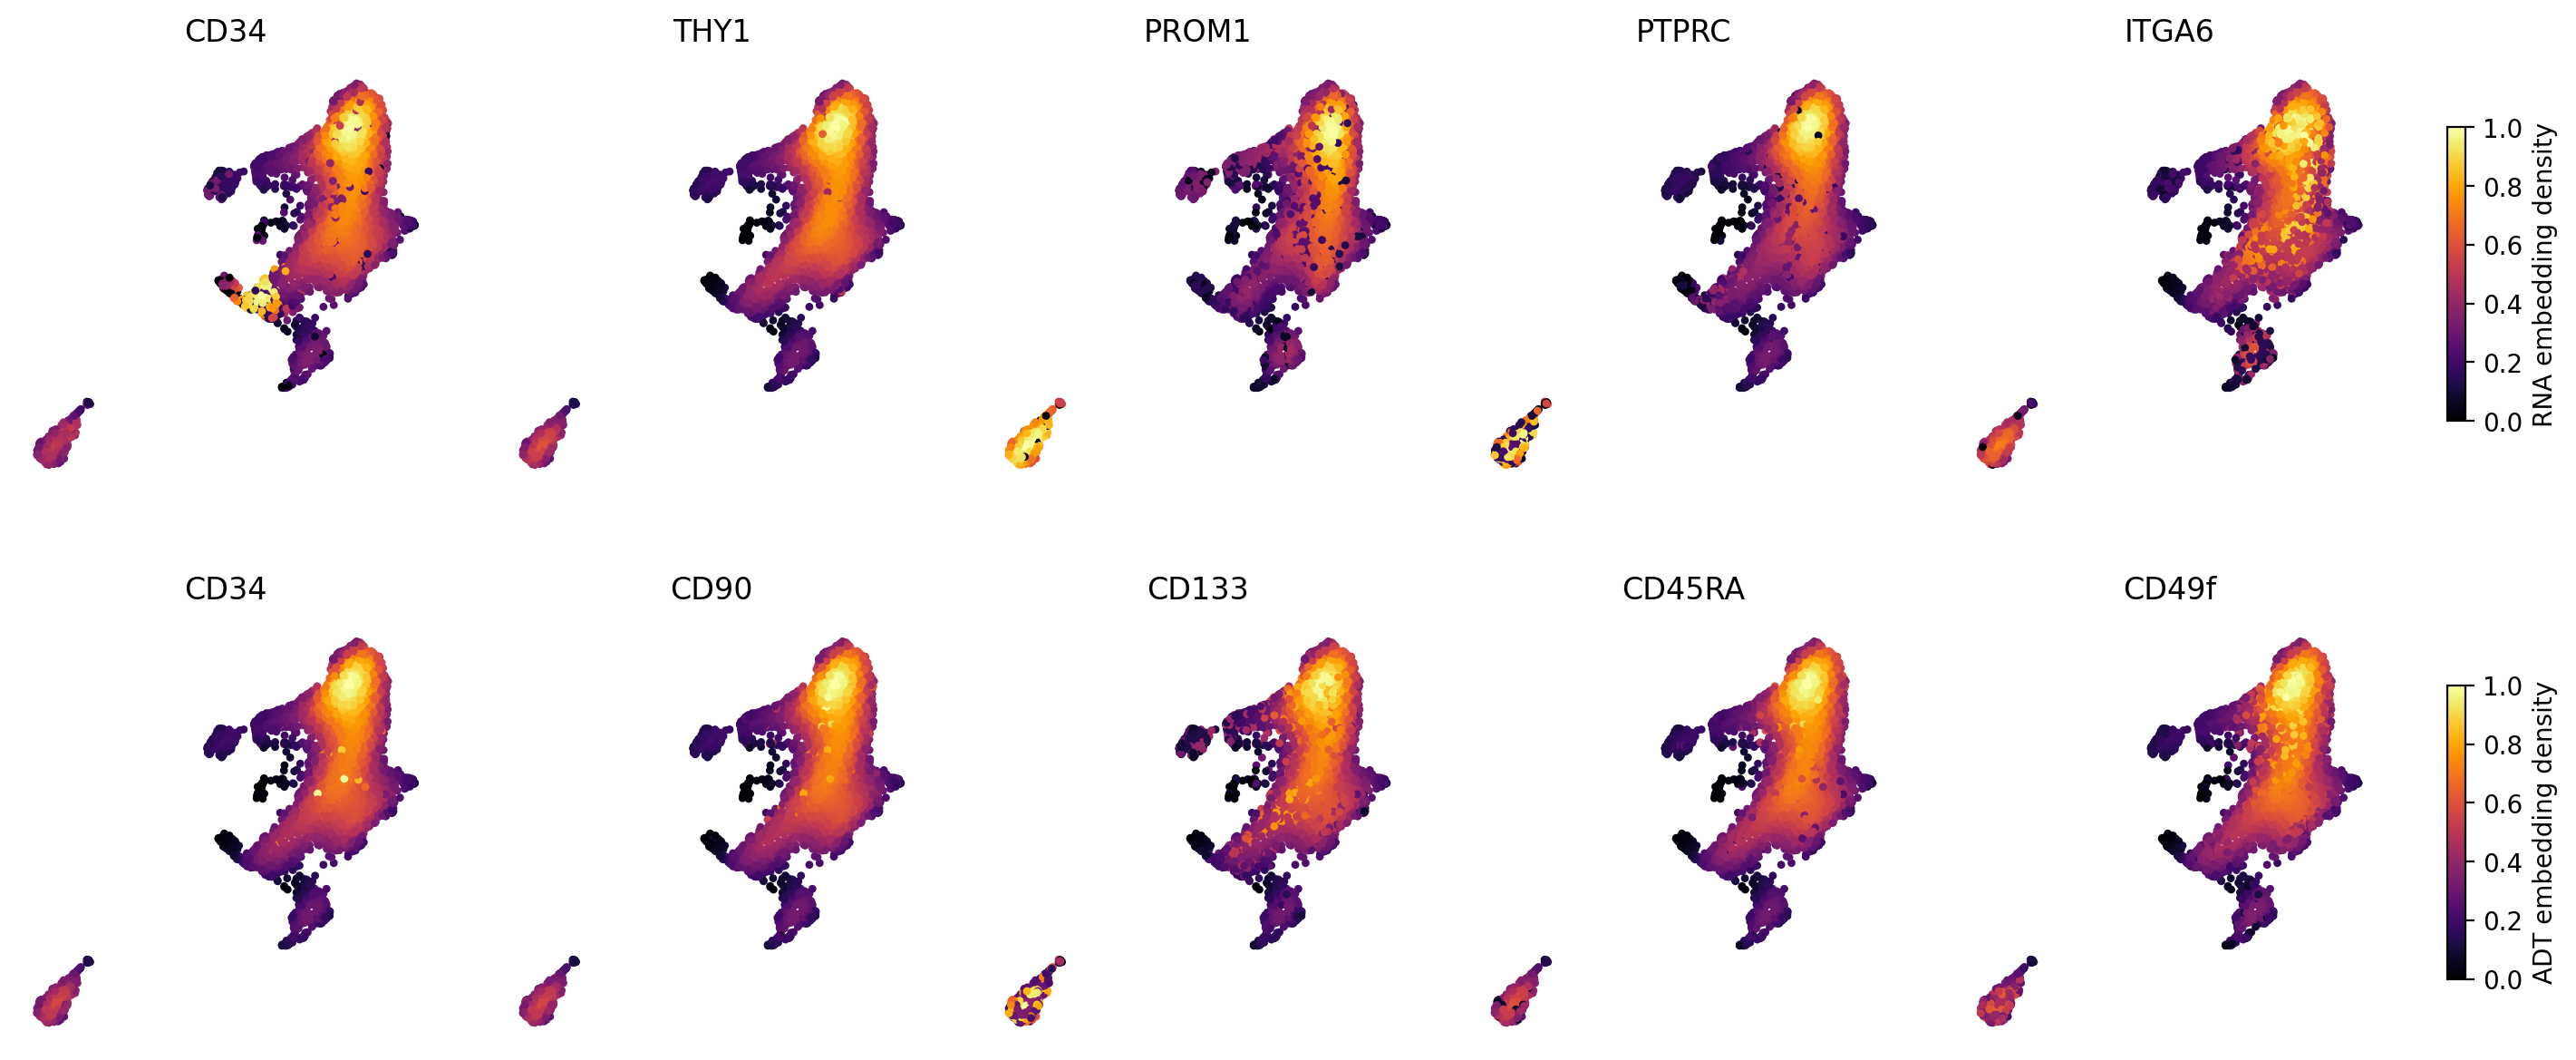

In [29]:
features = ['CD34', 'CD90', 'CD133', 'CD45RA', 'CD49f']   # ADT, log_ in obs
genes    = ['CD34', 'THY1', 'PROM1', 'PTPRC', 'ITGA6']    # RNA, in var
pairs    = list(zip(features, genes))

# UMAP coords
umap = adata.obsm["X_umap"]
x = umap[:, 0]
y = umap[:, 1]

gene_density = {}   # gene -> per-cell density (ndarray)
feat_density = {}   # feature -> per-cell density (ndarray)

basis = "umap"

# --- genes (RNA) ---
for gene in genes:
    expr = np.asarray(adata[:, gene].X).ravel()

    # binary group: expressing vs other, based on log > 0
    adata.obs[f"{gene}_expr_bin"] = pd.Categorical(
        np.where(expr > 0, f"{gene}_pos", "other")
    )

    key = f"{basis}_density_{gene}"
    sc.tl.embedding_density(
        adata,
        basis=basis,
        groupby=f"{gene}_expr_bin",
        key_added=key,
    )
    # Scanpy stores densities (scaled 0–1) in obs[key]
    gene_density[gene] = adata.obs[key].to_numpy()

# --- features (ADT, log_* in obs) ---
for feat in features:
    vals = adata.obs[f"log_{feat}"].astype(float).to_numpy()

    adata.obs[f"{feat}_expr_bin"] = pd.Categorical(
        np.where(vals > 0, f"{feat}_pos", "other")
    )

    key = f"{basis}_density_{feat}"
    sc.tl.embedding_density(
        adata,
        basis=basis,
        groupby=f"{feat}_expr_bin",
        key_added=key,
    )
    feat_density[feat] = adata.obs[key].to_numpy()

# All embedding_density outputs are scaled [0, 1]
rna_vmin, rna_vmax = 0.0, 1.0
adt_vmin, adt_vmax = 0.0, 1.0


n = len(pairs)
plt.rcParams['figure.dpi'] = 200

fig = plt.figure(figsize=(3.2*n + 1.5, 7))
gs = GridSpec(
    2, n + 1,
    width_ratios=[1]*n + [0.07],   # narrow colorbar column
    wspace=0.20,
    hspace=0.33
)

# ------------------ RNA density row ------------------
for j, (feat, gene) in enumerate(pairs):
    ax = fig.add_subplot(gs[0, j])

    dens = gene_density[gene]

    sc_rna = ax.scatter(
        x, y,
        c=dens,
        cmap="inferno",
        s=10,
        linewidths=0,
        vmin=rna_vmin,
        vmax=rna_vmax,
    )

    ax.text(
        0.5, 1.04, gene,
        transform=ax.transAxes,
        ha="center", va="bottom", fontsize=12
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

# Right vertical colorbar for RNA row
cax_rna = fig.add_subplot(gs[0, -1])
cb1 = fig.colorbar(sc_rna, cax=cax_rna, orientation="vertical")
cb1.set_label("RNA embedding density", fontsize=10)

# shrink & reposition this axes
box = cax_rna.get_position()
cax_rna.set_position([
    box.x0,                          # same x
    box.y0 + 0.15 * box.height,      # move up
    box.width * 0.6,                 # narrower
    box.height * 0.7,                # shorter
])

# ------------------ ADT density row ------------------
for j, (feat, gene) in enumerate(pairs):
    ax = fig.add_subplot(gs[1, j])

    dens = feat_density[feat]

    sc_adt = ax.scatter(
        x, y,
        c=dens,
        cmap="inferno",
        s=10,
        linewidths=0,
        vmin=adt_vmin,
        vmax=adt_vmax,
    )

    ax.text(
        0.5, 1.04, feat,
        transform=ax.transAxes,
        ha="center", va="bottom", fontsize=12
    )

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

# Right vertical colorbar for ADT row
cax_adt = fig.add_subplot(gs[1, -1])
cb2 = fig.colorbar(sc_adt, cax=cax_adt, orientation="vertical")
cb2.set_label("ADT embedding density", fontsize=10)

box = cax_adt.get_position()
cax_adt.set_position([
    box.x0,
    box.y0 + 0.15 * box.height,
    box.width * 0.6,
    box.height * 0.7,
])

plt.show()

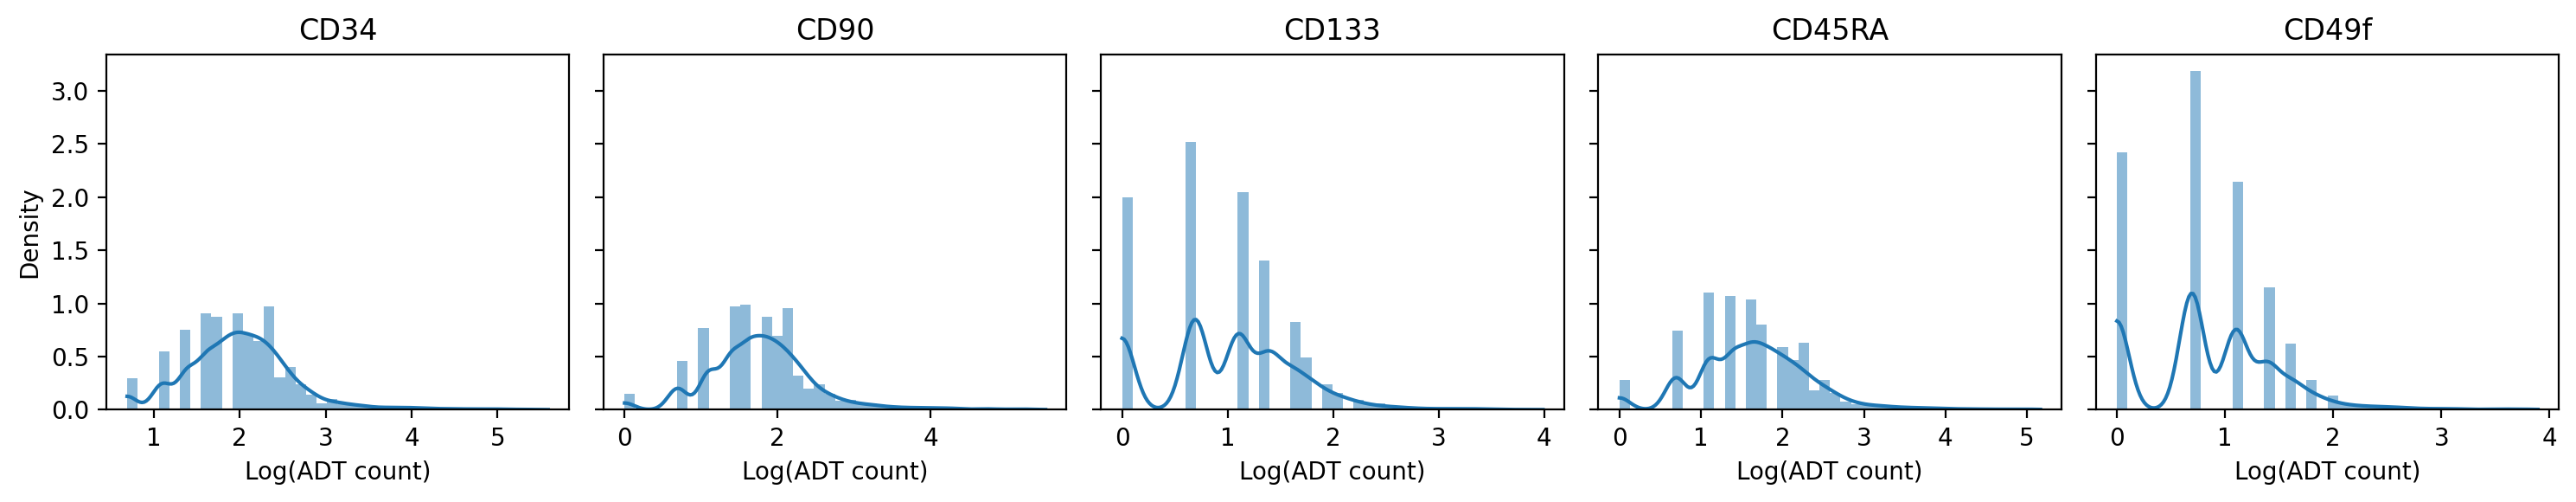

In [30]:
features = ['CD34', 'CD90', 'CD133', 'CD45RA', 'CD49f']
log_feats = [f"log_{f}" for f in features]

plt.rcParams['figure.dpi'] = 200

n = len(features)
fig, axes = plt.subplots(1, n, figsize=(3*n, 3), sharey=True)

for i, (feat, log_feat) in enumerate(zip(features, log_feats)):
    ax = axes[i]

    vals = adata.obs[log_feat].to_numpy(dtype=float)

    sns.histplot(
        vals,
        bins=40,
        kde=True,
        stat="density",
        ax=ax,
        element="step",
        edgecolor=None
    )

    ax.set_title(feat)
    ax.set_xlabel("Log(ADT count)")
    if i == 0:
        ax.set_ylabel("Density")
    else:
        ax.set_ylabel("")

plt.tight_layout()
plt.show()

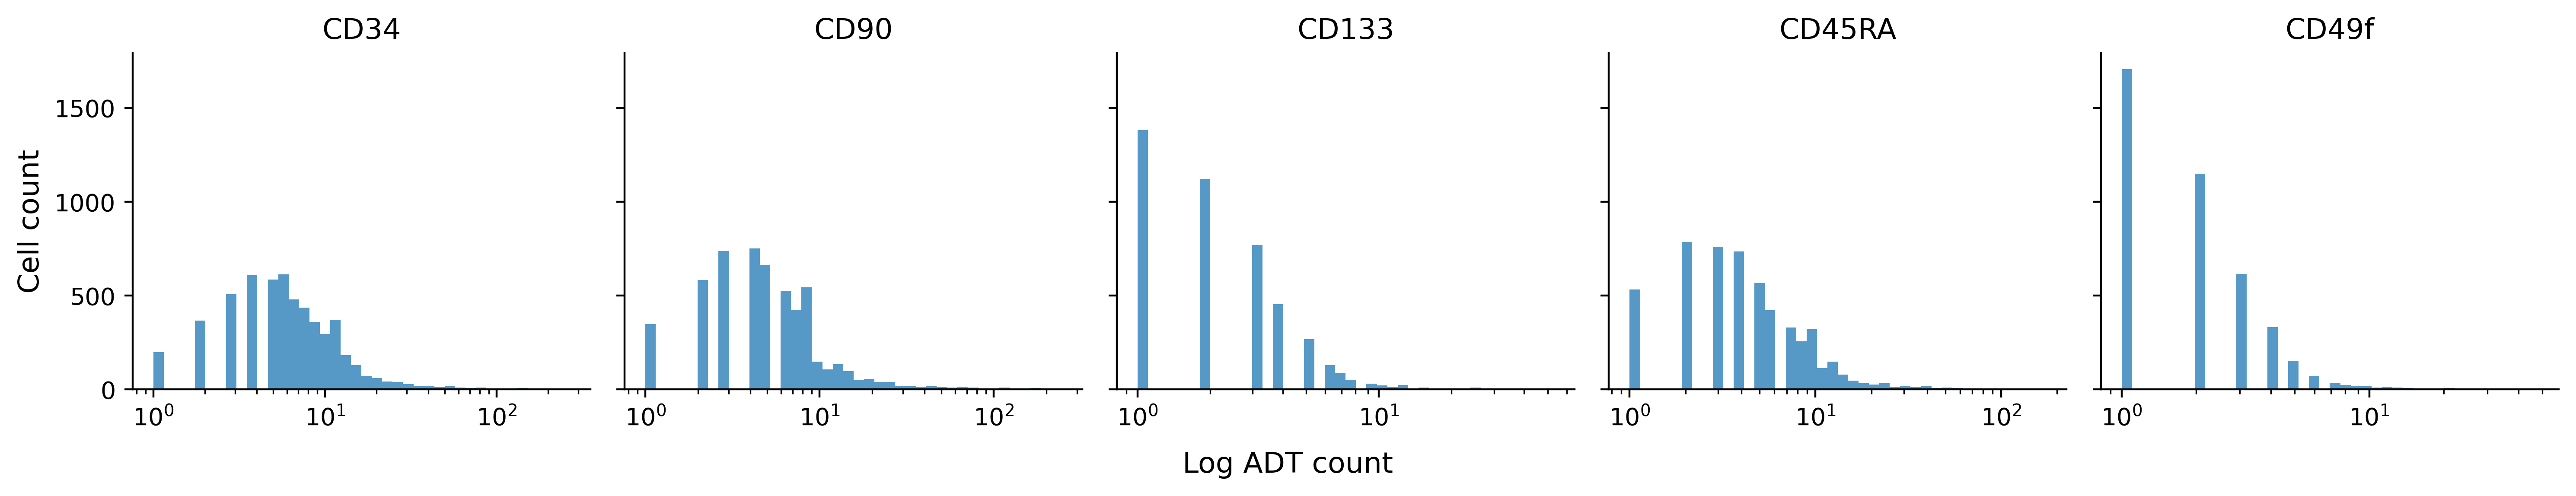

In [31]:
plt.rcParams['figure.dpi'] = 400
features = ['CD34_fb', 'CD90', 'CD133', 'CD45RA', 'CD49f']
n = len(features)
fig, axes = plt.subplots(1, n, figsize=(3*n, 3), sharey=True)

for i, f in enumerate(features):
    ax = axes[i]

    vals = adata.obs[f].to_numpy(dtype=float)

    sns.histplot(
        vals,
        bins=40,
        kde=False,
        stat="count",
        ax=ax,
        element="step",
        edgecolor=None,
        log_scale=True
    )

    sns.despine(ax=ax)
    if f=='CD34_fb':
        ax.set_title("CD34")
    else:
        ax.set_title(f)
    if i == 0:
        ax.set_ylabel("Cell count", fontsize=12)
    else:
        ax.set_ylabel("")
        
fig.suptitle("Log ADT count", y=0.01, fontsize=12)

plt.tight_layout()
plt.show()

In [32]:
adata

AnnData object with n_obs × n_vars = 5608 × 22954
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'leiden', 'bm_cluster', 'CD34_avg', 'CD164_avg', 'PROM1_avg', 'CD48_avg', 'FLT3_avg', 'MPO_avg', 'IRF8_avg', 'CD79A_avg', 'GATA1_avg', 'CD34pos_CD38neg_B0251_HTO_1', 'CD34pos_CD38pos_B0252_HTO_2', 'HTO_pred', 'HTO_pred_label', 'cluster_preds', 'CD164_mean', 'CD34_mean', 'CD38_mean', 'THY1_mean', 'PTPRC_mean', 'MME_mean', 'CD7_mean', 'FLT3_mean', 'PLEK_mean', 'BST2_mean', 'CD37_mean', 'KIT_mean', 'ICAM3_mean', 'CD44_mean', 'EVI2B_mean', 'CD63_mean', 'ITGA2B_mean', 'CSF2RB_mean', 'PROM1_mean', 'ATP1B3_mean',

In [33]:
adata.obs["cell_labels"] == "HSC"

AAACCAAAGGCGATCT-1    False
AAACCAAAGGTGAACG-1    False
AAACCATTCCCTGTCA-1    False
AAACCATTCCGCGATG-1     True
AAACCATTCCTGTCGC-1    False
                      ...  
TGTGTACGTTAGAGCA-1    False
TGTGTTAGTAAGCGTA-1    False
TGTGTTAGTAATGCCT-1    False
TGTGTTAGTATTGCTA-1    False
TGTGTTAGTTAGGTGA-1    False
Name: cell_labels, Length: 5608, dtype: bool

In [34]:
adata.obs["cell_labels"].describe()

count     5608
unique       7
top        MPP
freq      2225
Name: cell_labels, dtype: object

In [35]:
fpath = "/scratch/indikar_root/indikar1/sgolts/5k_pbmc_protein_v3_nextgem_filtered_feature_bc_matrix.h5"
bdata = sc.read_10x_h5(fpath)
bdata

reading /scratch/indikar_root/indikar1/sgolts/5k_pbmc_protein_v3_nextgem_filtered_feature_bc_matrix.h5
 (0:00:01)


/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.13/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.13/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 5527 × 33538
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

In [36]:
bdata.obs.head()


""
AAACCCACAGGCTTGC-1
AAACCCAGTAGTTAGA-1
AAACGAAGTAACGATA-1
AAACGAAGTGGATCAG-1
AAACGAATCATGAGAA-1


## Some Notes

- Exclude cells with no CD34 fb
- When cells are dying in flow, they tend to be positive for everything
- If people gave a report of reads/cell and reads overall in a population

In [ ]:
sc.pl.umap(
    adata,
    color='cell_labels',
    palette='turbo',
    size=25,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

## MEG/ERY --> MEPs
## NA --> GMPs

In [ ]:
features = ['CD34', 'CD90', 'CD133', 'CD45RA', 'CD49f']
# thy1 = cd90, prom1 = cd133, ptprc = CD45RA, itga6 = cd49f
# cd45ra is an isoform!!
genes = ['CD34', 'THY1', 'PROM1', 'PTPRC', 'ITGA6'] 

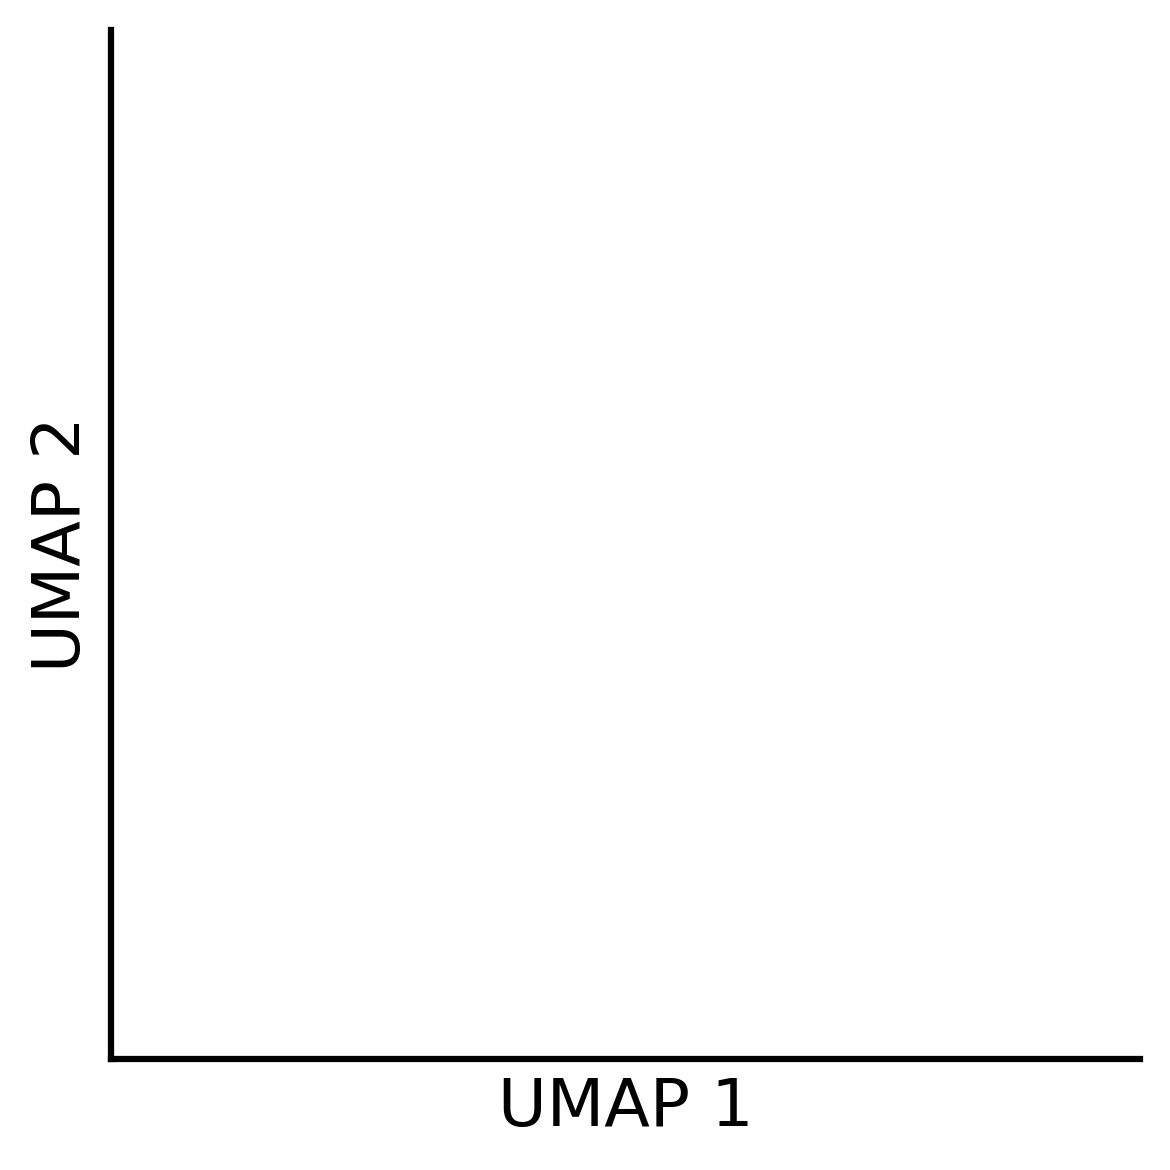

In [99]:
plt.rcParams['figure.dpi'] = 300

fig, ax = plt.subplots(figsize=(4, 4))

# Transparent background
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# Set axis limits to something reasonable
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)

# Axis labels
ax.set_xlabel("UMAP 1", fontsize=16)
ax.set_ylabel("UMAP 2", fontsize=16)

# Remove ticks + tick labels
ax.set_xticks([])
ax.set_yticks([])

# Remove grid
ax.grid(False)

# Keep only bottom + left axis lines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

# Make sure layout doesn't clip labels
plt.tight_layout()

plt.show()